# CS3807 — Deep Learning Lab, Experiment 5




---
##  Setup

In [ ]:
!pip uninstall -y protobuf tensorflow tensorflow-datasets
!pip install -U tensorflow tensorflow-datasets protobuf

Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tensorflow-datasets 4.9.10
Uninstalling tensorflow-datasets-4.9.10:
  Successfully uninstalled tensorflow-datasets-4.9.10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 77.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fo

In [ ]:

import gc, os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({'figure.figsize':(12,4),'font.size':11,
                     'axes.grid':True,'grid.alpha':0.3})
sns.set_style('whitegrid')
os.makedirs('./outputs', exist_ok=True)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

def free_mem():
    """Call this after every experiment to reclaim RAM."""
    keras.backend.clear_session()
    gc.collect()

print('Setup done.')

TF: 2.21.0
GPU: []
Setup done.


In [ ]:
# ── Lightweight configuration ────────────────────────────────────────────
IMG_SIZE    = 128        # 128x128 instead of 224x224 → ~3x less RAM
NUM_CLASSES = 10         # 10 breeds instead of 37 → faster, lighter
BATCH_SIZE  = 32
EPOCHS      = 8          # 8 epochs per experiment
AUTOTUNE    = tf.data.AUTOTUNE

# 10 breed names we will keep
KEEP_BREEDS = [
    'Abyssinian','Bengal','Birman','Bombay','British_Shorthair',
    'Egyptian_Mau','Maine_Coon','Persian','Ragdoll','Russian_Blue'
]
print(f'Image size   : {IMG_SIZE}x{IMG_SIZE}')
print(f'Classes kept : {NUM_CLASSES}')
print(f'Breeds       : {KEEP_BREEDS}')


Image size   : 128x128
Classes kept : 10
Breeds       : ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue']


---
## 🐾 Dataset

In [ ]:
!pip install importlib_resources

In [ ]:
# Load full dataset then filter to 10 breeds
(raw_tr_full, raw_val_full, raw_te_full), info = tfds.load(
    'oxford_iiit_pet',
    split=['train[:70%]','train[70%:85%]','train[85%:]'],
    with_info=True, as_supervised=True, shuffle_files=True
)

ALL_BREEDS  = info.features['label'].names
KEEP_IDS    = [ALL_BREEDS.index(b) for b in KEEP_BREEDS if b in ALL_BREEDS]
BREED_REMAP = {old: new for new, old in enumerate(KEEP_IDS)}
print('Kept breed IDs:', KEEP_IDS)

def filter_and_remap(img, lbl):
    keep = tf.reduce_any([tf.equal(lbl, k) for k in KEEP_IDS])
    new_lbl = tf.constant(0, dtype=tf.int64)
    for new_id, old_id in enumerate(KEEP_IDS):
        new_lbl = tf.where(tf.equal(lbl, old_id),
                           tf.constant(new_id, dtype=tf.int64), new_lbl)
    return img, new_lbl, keep

def apply_filter(ds):
    ds = ds.map(lambda i,l: filter_and_remap(i,l), num_parallel_calls=AUTOTUNE)
    ds = ds.filter(lambda i, l, k: k)
    return ds.map(lambda i, l, k: (i, l), num_parallel_calls=AUTOTUNE)

raw_train = apply_filter(raw_tr_full)
raw_val   = apply_filter(raw_val_full)
raw_test  = apply_filter(raw_te_full)

n_tr  = sum(1 for _ in raw_train)
n_val = sum(1 for _ in raw_val)
n_te  = sum(1 for _ in raw_test)
print(f'Train: {n_tr} | Val: {n_val} | Test: {n_te}')


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.VNUVYE_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.VNUVYE_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Kept breed IDs: [0, 5, 6, 7, 9, 11, 20, 23, 26, 27]
Train: 695 | Val: 144 | Test: 150


In [ ]:
# Preprocessing — 128x128, MobileNetV2 normalisation
def preprocess(img, lbl):
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)   # scales to [-1, 1]
    return img, lbl

def augment(img, lbl):
    img, lbl = preprocess(img, lbl)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    return img, lbl

# No .cache() — saves RAM, slightly slower
def make_ds(raw, aug=False, shuffle=False, batch=BATCH_SIZE):
    fn = augment if aug else preprocess
    ds = raw.map(fn, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(512, seed=42)
    return ds.batch(batch).prefetch(AUTOTUNE)

train_data = make_ds(raw_train, aug=True,  shuffle=True)
val_data   = make_ds(raw_val)
test_data  = make_ds(raw_test)

for imgs, lbls in train_data.take(1):
    print(f'Batch: {imgs.shape}, range=[{imgs.numpy().min():.1f}, {imgs.numpy().max():.1f}]')


Batch: (32, 128, 128, 3), range=[-1.1, 1.1]


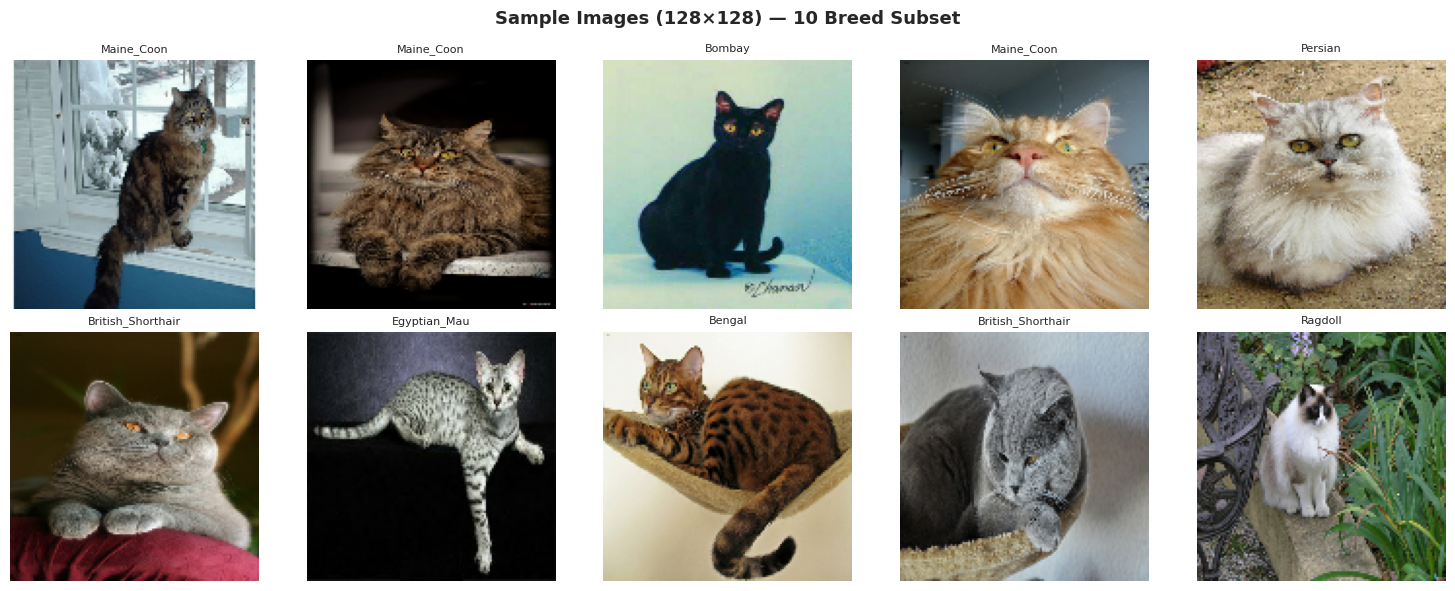

In [ ]:
# Sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images (128×128) — 10 Breed Subset', fontsize=13, fontweight='bold')
it = iter(raw_train.shuffle(200, seed=1))
for ax in axes.flat:
    img, lbl = next(it)
    ax.imshow(tf.image.resize(img,[IMG_SIZE,IMG_SIZE]).numpy().astype('uint8'))
    ax.set_title(KEEP_BREEDS[lbl.numpy()], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('./outputs/samples.png', dpi=90)
plt.show()


---
##  Model Builders & Helpers

In [ ]:
def build_frozen(dropout=0.3, l2=0.0, batchnorm=True):
    """Pretrained MobileNetV2 frozen; train only new head."""
    base = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                       include_top=False, weights='imagenet')
    base.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    if batchnorm:
        x = layers.BatchNormalization()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    reg = regularizers.l2(l2) if l2 > 0 else None
    x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out)


def build_scratch(init_name='he_normal', dropout=0.3):
    """MobileNetV2 from scratch — for initialization experiments."""
    base = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                       include_top=False, weights=None)
    base.trainable = True
    init = keras.initializers.get(init_name)
    for lyr in base.layers:
        if hasattr(lyr,'kernel') and lyr.kernel is not None:
            try:
                lyr.kernel.assign(init(shape=lyr.kernel.shape, dtype=tf.float32))
            except Exception:
                pass
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax',
                       kernel_initializer=init_name)(x)
    return Model(inputs=base.input, outputs=out)


def build_finetune(unfreeze=30, dropout=0.3):
    """Pretrained MobileNetV2 with top layers unfrozen."""
    base = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                       include_top=False, weights='imagenet')
    base.trainable = True
    for lyr in base.layers[:-unfreeze]:
        lyr.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out)


def run(model, opt, tr=train_data, vl=val_data, epochs=EPOCHS, v=1, tag=''):
    """Compile, fit, clear session, return history."""
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    t0 = time.time()
    h  = model.fit(tr, validation_data=vl, epochs=epochs, verbose=v)
    t  = time.time()-t0
    bva = max(h.history['val_accuracy'])
    if tag: print(f'[{tag}] {t:.0f}s | best_val={bva:.4f}')
    free_mem()
    return h, t


print('Builders ready.')


Builders ready.


---
##  Experiment 1: Weight Initialization

Training MobileNetV2 **from scratch** with four different initializers.
Goal: see which starts converging fastest and most stably.

In [ ]:
INITS = {
    'Zero Init'    : 'zeros',
    'Random Normal': 'random_normal',
    'Xavier/Glorot': 'glorot_uniform',
    'He Normal'    : 'he_normal',
}
hist_init = {}

for name, cfg in INITS.items():
    print(f'--- {name} ---')
    m = build_scratch(init_name=cfg)
    h, _ = run(m, keras.optimizers.Adam(1e-3), epochs=EPOCHS, tag=name)
    hist_init[name] = h

print('Exp 1 done.')


--- Zero Init ---
Epoch 1/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.0820 - loss: 2.3029 - val_accuracy: 0.1250 - val_loss: 2.3024
Epoch 2/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.0878 - loss: 2.3025 - val_accuracy: 0.0764 - val_loss: 2.3029
Epoch 3/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.1151 - loss: 2.3023 - val_accuracy: 0.0764 - val_loss: 2.3030
Epoch 4/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.1151 - loss: 2.3021 - val_accuracy: 0.0764 - val_loss: 2.3034
Epoch 5/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.1151 - loss: 2.3019 - val_accuracy: 0.0764 - val_loss: 2.3035
Epoch 6/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.1151 - loss: 2.3018 - val_accuracy: 0.0764 - val_loss: 2.3038
Epoch 7/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.1151 - loss: 2.3016 - val_accuracy: 0.0764 - val_loss: 2.3040
Epoch 8/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.1151 - loss: 2.3015 - val_accuracy: 0.0764 -

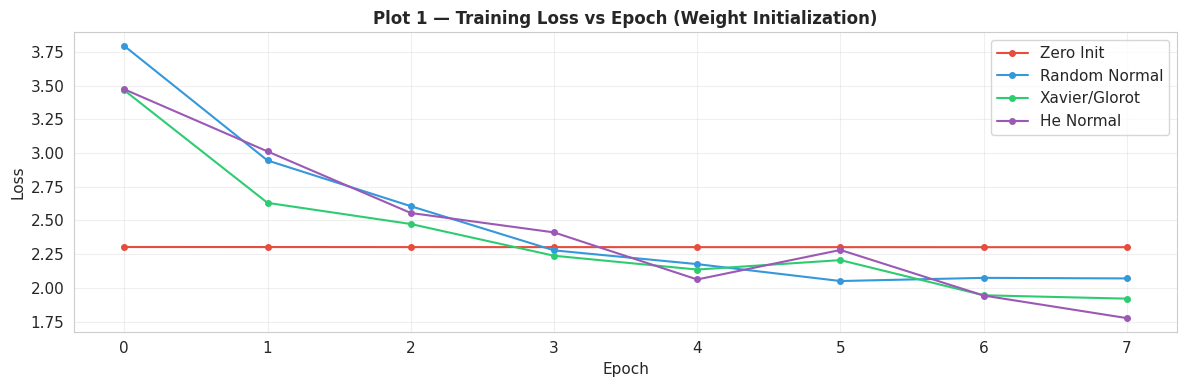

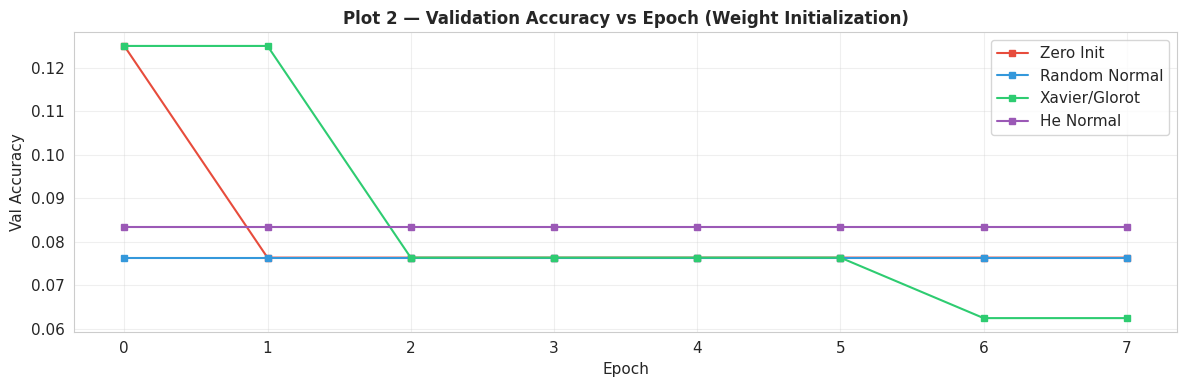

Initializer            Best Val Acc
------------------------------------
Zero Init                    0.1250
Random Normal                0.0764
Xavier/Glorot                0.1250
He Normal                    0.0833

Inference:
  Zero Init    : Nearly flat loss — symmetry prevents diverse features.
  Random Normal: Converges but may be noisy at start.
  Xavier/Glorot: Smooth convergence; designed for tanh but still useful.
  He Normal    : Fastest, most stable — optimal for ReLU networks.



In [ ]:
CLR = ['#e74c3c','#3498db','#2ecc71','#9b59b6']

# Plot 1 — Training Loss
plt.figure(figsize=(12,4))
for (n,h),c in zip(hist_init.items(),CLR):
    plt.plot(h.history['loss'], marker='o', ms=4, color=c, label=n)
plt.title('Plot 1 — Training Loss vs Epoch (Weight Initialization)',
          fontsize=12, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.savefig('./outputs/plot1_init_loss.png', dpi=90); plt.show()

# Plot 2 — Validation Accuracy
plt.figure(figsize=(12,4))
for (n,h),c in zip(hist_init.items(),CLR):
    plt.plot(h.history['val_accuracy'], marker='s', ms=4, color=c, label=n)
plt.title('Plot 2 — Validation Accuracy vs Epoch (Weight Initialization)',
          fontsize=12, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()
plt.tight_layout(); plt.savefig('./outputs/plot2_init_valacc.png', dpi=90); plt.show()

print(f'{"Initializer":<20} {"Best Val Acc":>14}')
print('-'*36)
for n,h in hist_init.items():
    print(f'{n:<20} {max(h.history["val_accuracy"]):>14.4f}')

print("""
Inference:
  Zero Init    : Nearly flat loss — symmetry prevents diverse features.
  Random Normal: Converges but may be noisy at start.
  Xavier/Glorot: Smooth convergence; designed for tanh but still useful.
  He Normal    : Fastest, most stable — optimal for ReLU networks.
""")


---
##  Experiment 2: Regularization & Overfitting

Frozen pretrained MobileNetV2 base, different classifier heads.

In [ ]:
def build_reg_head(mode):
    base = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                       include_top=False, weights='imagenet')
    base.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    if mode == 'none':
        x = layers.Dense(128, activation='relu')(x)
    elif mode == 'l2':
        x = layers.Dense(128, activation='relu',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
    elif mode == 'dropout':
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
    elif mode == 'batchnorm':
        x = layers.Dense(128, activation='relu')(x)
        x = layers.BatchNormalization()(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out)

REG_MODES = {
    'No Regularization': 'none',
    'L2 Regularization': 'l2',
    'Dropout (0.5)'    : 'dropout',
    'Batch Norm'       : 'batchnorm',
}
hist_reg = {}
for name, mode in REG_MODES.items():
    print(f'--- {name} ---')
    h, _ = run(build_reg_head(mode), keras.optimizers.Adam(1e-3), tag=name)
    hist_reg[name] = h
print('Exp 2 done.')


--- No Regularization ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 680ms/step - accuracy: 0.5856 - loss: 1.2752 - val_accuracy: 0.7500 - val_loss: 0.6615
Epoch 2/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 648ms/step - accuracy: 0.9065 - loss: 0.3131 - val_accuracy: 0.8125 - val_loss: 0.4662
Epoch 3/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 751ms/step - accuracy: 0.9554 - loss: 0.1494 - val_accuracy: 0.8542 - val_loss: 0.3925
Epoch 4/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 594ms/step - accuracy: 0.9827 - loss: 0.0962 - val_accuracy: 0.8750 - val_loss: 0.3712
Epoch 5/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 715ms/step - accuracy: 0.9986 - loss: 0.0518 - val_accuracy: 0.8819 - val_loss: 0.4013
Epoch 6/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 604ms/step - accuracy: 0.9928 - loss: 0.0481 - val_accuracy: 0.8750 - val_loss: 0.4054
Epoch 7/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 600ms/step - accuracy: 1.0000 - loss: 0.0307 - val_accuracy: 0.8889 - val_loss: 0.3873
Epoch 8/8
22/22 ━━━━━━━━━━━━━

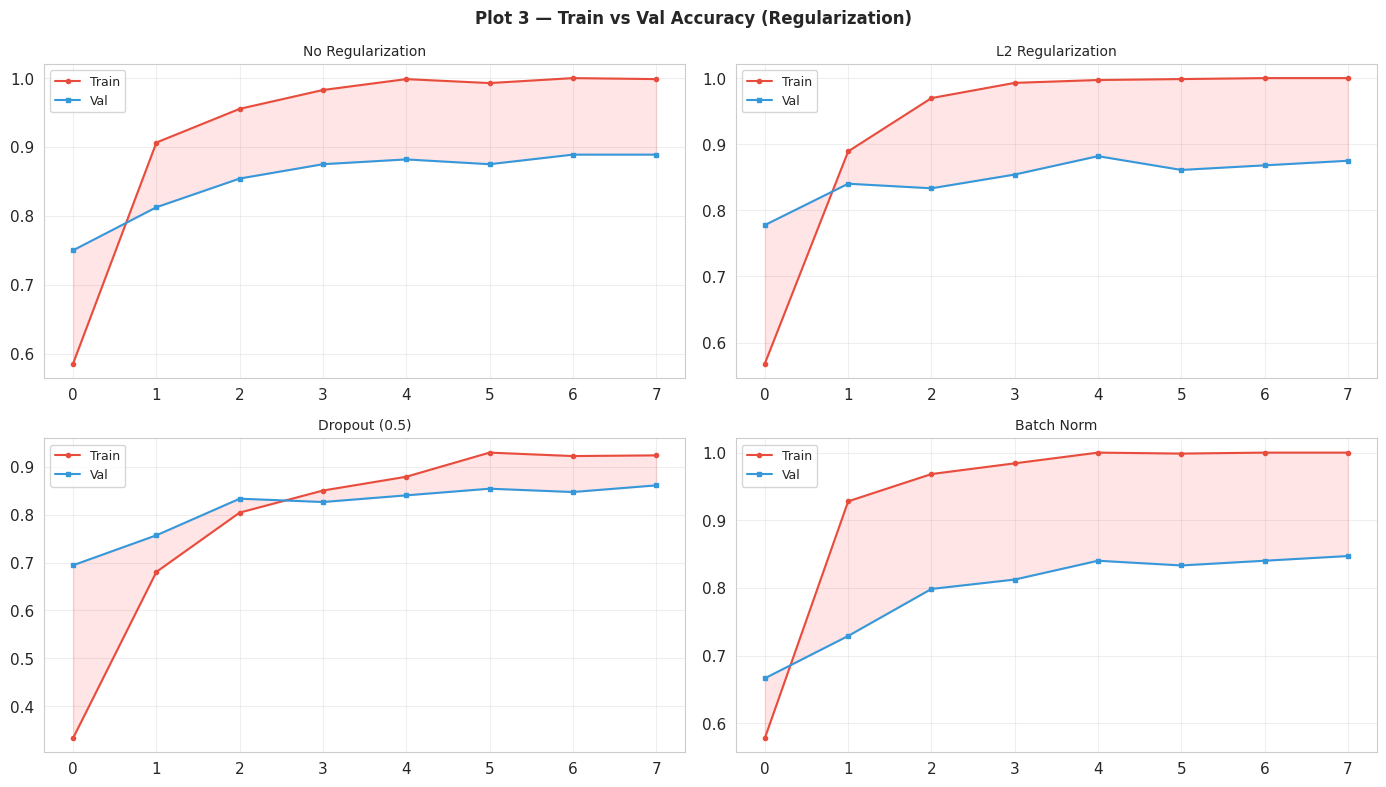

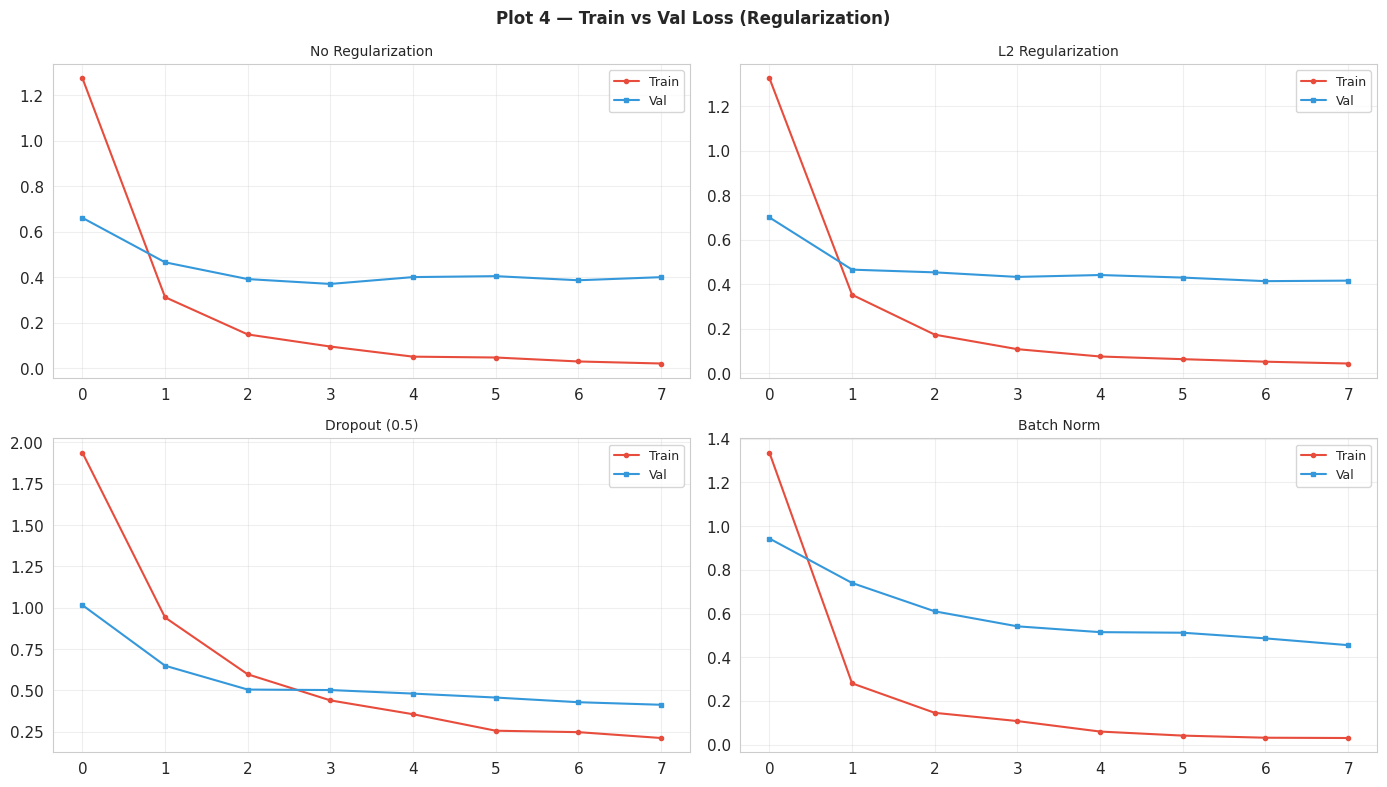


Inference (Plots 3 & 4):
  No Reg  : Widest shaded gap — clearest overfitting.
  Dropout : Reduces gap by forcing redundant representations.
  BN      : Narrows gap + faster convergence due to stable activations.
  L2      : Penalises large weights, smoothing decision boundaries.



In [ ]:
# Plot 3 — Train vs Val Accuracy
fig, axes = plt.subplots(2, 2, figsize=(14,8))
fig.suptitle('Plot 3 — Train vs Val Accuracy (Regularization)',
             fontsize=12, fontweight='bold')
for ax, (name, h) in zip(axes.flat, hist_reg.items()):
    tr = h.history['accuracy']
    vl = h.history['val_accuracy']
    ep = range(len(tr))
    ax.plot(ep, tr, label='Train', color='#e74c3c', marker='o', ms=3)
    ax.plot(ep, vl, label='Val',   color='#3498db', marker='s', ms=3)
    ax.fill_between(ep, vl, tr, alpha=0.1, color='red')
    ax.set_title(name, fontsize=10); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('./outputs/plot3_reg_acc.png', dpi=90); plt.show()

# Plot 4 — Train vs Val Loss
fig, axes = plt.subplots(2, 2, figsize=(14,8))
fig.suptitle('Plot 4 — Train vs Val Loss (Regularization)',
             fontsize=12, fontweight='bold')
for ax, (name, h) in zip(axes.flat, hist_reg.items()):
    ax.plot(h.history['loss'],     label='Train', color='#e74c3c', marker='o', ms=3)
    ax.plot(h.history['val_loss'], label='Val',   color='#3498db', marker='s', ms=3)
    ax.set_title(name, fontsize=10); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('./outputs/plot4_reg_loss.png', dpi=90); plt.show()

print("""
Inference (Plots 3 & 4):
  No Reg  : Widest shaded gap — clearest overfitting.
  Dropout : Reduces gap by forcing redundant representations.
  BN      : Narrows gap + faster convergence due to stable activations.
  L2      : Penalises large weights, smoothing decision boundaries.
""")


---
##  Experiment 3: Batch Normalization

In [ ]:
# Numerical demo
x   = np.array([2.,4.,6.,8.])
mu  = x.mean(); sigma2 = x.var()
xh  = (x - mu) / np.sqrt(sigma2 + 1e-5)
print('Batch Normalization — Numerical Demo')
print(f'  x      = {x}')
print(f'  mean   = {mu:.2f}  var = {sigma2:.2f}  std = {np.sqrt(sigma2):.4f}')
print(f'  x_hat  = {np.round(xh,4)}')
print('  With gamma=1, beta=0: zero-centred, unit-variance output.')


Batch Normalization — Numerical Demo
  x      = [2. 4. 6. 8.]
  mean   = 5.00  var = 5.00  std = 2.2361
  x_hat  = [-1.3416 -0.4472  0.4472  1.3416]
  With gamma=1, beta=0: zero-centred, unit-variance output.


--- With BN ---
Epoch 1/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 676ms/step - accuracy: 0.5079 - loss: 1.5763 - val_accuracy: 0.6389 - val_loss: 1.0936
Epoch 2/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 601ms/step - accuracy: 0.8676 - loss: 0.3991 - val_accuracy: 0.7569 - val_loss: 0.7519
Epoch 3/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 593ms/step - accuracy: 0.9237 - loss: 0.2463 - val_accuracy: 0.8125 - val_loss: 0.6018
Epoch 4/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 578ms/step - accuracy: 0.9554 - loss: 0.1778 - val_accuracy: 0.8056 - val_loss: 0.5504
Epoch 5/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 598ms/step - accuracy: 0.9741 - loss: 0.1252 - val_accuracy: 0.8333 - val_loss: 0.5521
Epoch 6/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 610ms/step - accuracy: 0.9827 - loss: 0.0963 - val_accuracy: 0.8333 - val_loss: 0.5344
Epoch 7/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 572ms/step - accuracy: 0.9885 - loss: 0.0739 - val_accuracy: 0.8333 - val_loss: 0.5278
Epoch 8/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 602ms/step - accuracy: 0.9856 - loss: 0.0713 - 

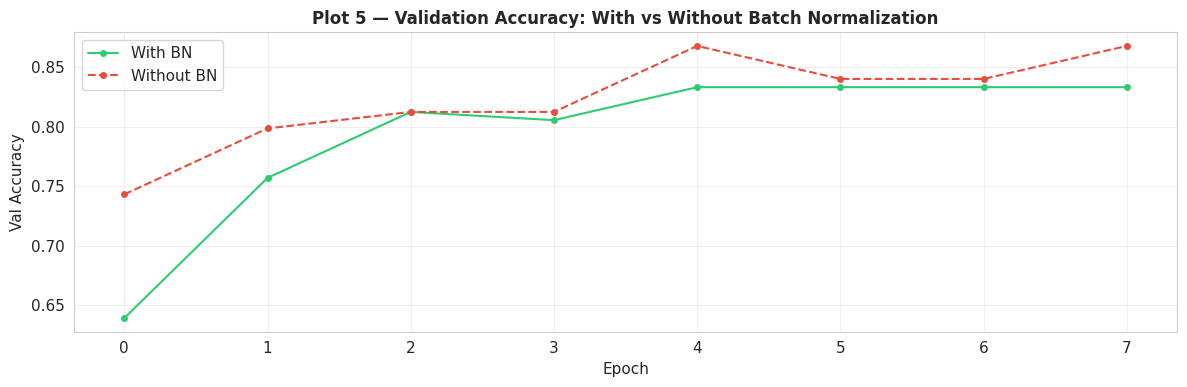


Inference:
  With BN (green): higher val accuracy, reached sooner — stable activations
  let the optimizer use larger effective steps without diverging.
  Without BN (dashed red): noisier, slower convergence.



In [ ]:
def build_bn_compare(use_bn):
    base = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                       include_top=False, weights='imagenet')
    base.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out)

hist_bn = {}
for label, flag in [('With BN', True), ('Without BN', False)]:
    print(f'--- {label} ---')
    h, _ = run(build_bn_compare(flag), keras.optimizers.Adam(1e-3), tag=label)
    hist_bn[label] = h

# Plot 5
plt.figure(figsize=(12,4))
styles = {'With BN':('solid','#2ecc71'), 'Without BN':('dashed','#e74c3c')}
for label, h in hist_bn.items():
    ls, c = styles[label]
    plt.plot(h.history['val_accuracy'], ls=ls, color=c, marker='o', ms=4, label=label)
plt.title('Plot 5 — Validation Accuracy: With vs Without Batch Normalization',
          fontsize=12, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()
plt.tight_layout(); plt.savefig('./outputs/plot5_bn.png', dpi=90); plt.show()

print("""
Inference:
  With BN (green): higher val accuracy, reached sooner — stable activations
  let the optimizer use larger effective steps without diverging.
  Without BN (dashed red): noisier, slower convergence.
""")


---
##  Experiment 4: Optimization Algorithms

In [ ]:
# Lambdas so each run gets a fresh optimizer
OPT_FNS = {
    'SGD'     : lambda: keras.optimizers.SGD(0.01),
    'Momentum': lambda: keras.optimizers.SGD(0.01, momentum=0.9),
    'RMSProp' : lambda: keras.optimizers.RMSprop(1e-3),
    'Adam'    : lambda: keras.optimizers.Adam(1e-3),
}
hist_opt  = {}
time_opt  = {}
OPT_CLR   = {'SGD':'#e74c3c','Momentum':'#f39c12',
             'RMSProp':'#3498db','Adam':'#2ecc71'}

for name, fn in OPT_FNS.items():
    print(f'--- {name} ---')
    h, t = run(build_frozen(dropout=0.3), fn(), tag=name)
    hist_opt[name] = h; time_opt[name] = t

print('Exp 4 done.')


--- SGD ---
Epoch 1/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 679ms/step - accuracy: 0.1914 - loss: 2.4494 - val_accuracy: 0.2778 - val_loss: 1.9160
Epoch 2/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 680ms/step - accuracy: 0.5151 - loss: 1.4026 - val_accuracy: 0.4861 - val_loss: 1.4774
Epoch 3/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 597ms/step - accuracy: 0.6691 - loss: 0.9893 - val_accuracy: 0.6389 - val_loss: 1.2061
Epoch 4/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 563ms/step - accuracy: 0.7281 - loss: 0.8047 - val_accuracy: 0.6597 - val_loss: 1.0224
Epoch 5/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 658ms/step - accuracy: 0.7928 - loss: 0.6581 - val_accuracy: 0.7222 - val_loss: 0.8967
Epoch 6/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 606ms/step - accuracy: 0.8029 - loss: 0.5781 - val_accuracy: 0.7292 - val_loss: 0.8197
Epoch 7/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 659ms/step - accuracy: 0.8417 - loss: 0.4840 - val_accuracy: 0.7500 - val_loss: 0.7488
Epoch 8/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 594ms/step - accuracy: 0.8676 - loss: 0.4380 - val_

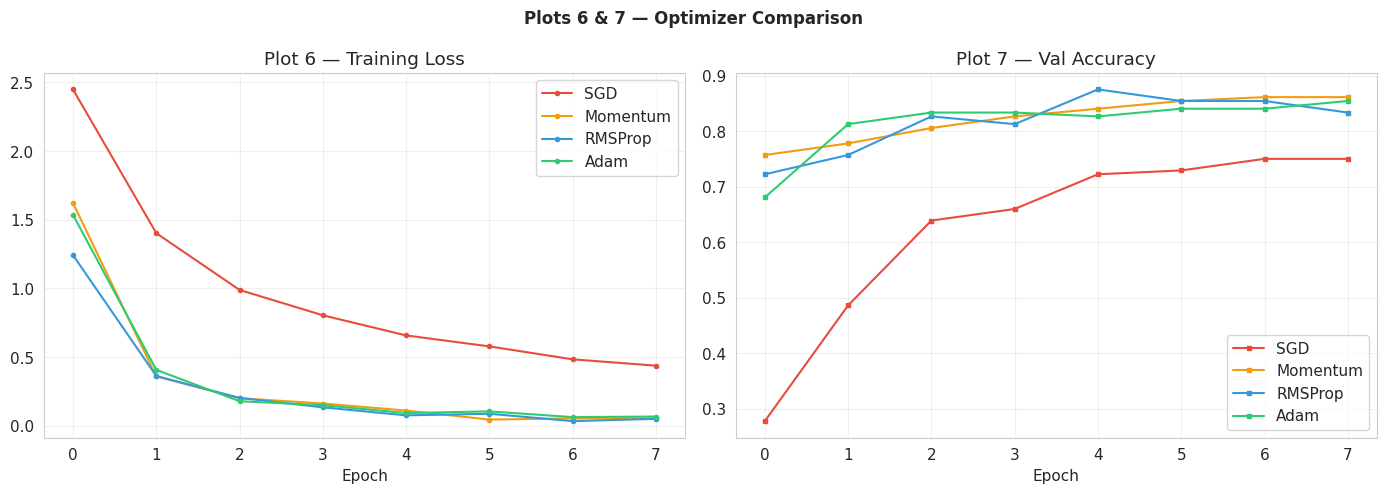

Optimizer     Final Loss  Best Val Acc   Time(s)
------------------------------------------------
SGD               0.4380        0.7500     179.2
Momentum          0.0543        0.8611     160.2
RMSProp           0.0508        0.8750     161.4
Adam              0.0676        0.8542     181.7

Inference:
  SGD      : Slowest — no momentum, no adaptive LR.
  Momentum : Faster than SGD; accumulates velocity in consistent gradient directions.
  RMSProp  : Adaptive per-parameter LR; handles loss landscape curvature better.
  Adam     : Best default — combines momentum and adaptive LR.



In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Plots 6 & 7 — Optimizer Comparison', fontsize=12, fontweight='bold')

for n, h in hist_opt.items():
    ax1.plot(h.history['loss'],         marker='o', ms=3, color=OPT_CLR[n], label=n)
    ax2.plot(h.history['val_accuracy'], marker='s', ms=3, color=OPT_CLR[n], label=n)

ax1.set_title('Plot 6 — Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.set_title('Plot 7 — Val Accuracy');  ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig('./outputs/plots6_7_opt.png', dpi=90); plt.show()

print(f'{"Optimizer":<12} {"Final Loss":>11} {"Best Val Acc":>13} {"Time(s)":>9}')
print('-'*48)
for n in hist_opt:
    print(f'{n:<12} {hist_opt[n].history["loss"][-1]:>11.4f}'
          f' {max(hist_opt[n].history["val_accuracy"]):>13.4f}'
          f' {time_opt[n]:>9.1f}')

print("""
Inference:
  SGD      : Slowest — no momentum, no adaptive LR.
  Momentum : Faster than SGD; accumulates velocity in consistent gradient directions.
  RMSProp  : Adaptive per-parameter LR; handles loss landscape curvature better.
  Adam     : Best default — combines momentum and adaptive LR.
""")


---
##  Experiment 5: Hyperparameter Tuning

Change **one thing at a time**, keep everything else fixed.

In [ ]:
# CNN formula demo
def cout(N,K,P,S): return (N+2*P-K)//S+1
print('O = floor((N + 2P - K) / S) + 1')
for args in [(128,3,1,1),(128,3,1,2),(64,1,0,1),(32,3,0,1)]:
    print(f'  N={args[0]}, K={args[1]}, P={args[2]}, S={args[3]} -> {cout(*args)}')


O = floor((N + 2P - K) / S) + 1
  N=128, K=3, P=1, S=1 -> 128
  N=128, K=3, P=1, S=2 -> 64
  N=64, K=1, P=0, S=1 -> 64
  N=32, K=3, P=0, S=1 -> 30


  LR=1e-02 -> 0.8194
  LR=1e-03 -> 0.8403
  LR=1e-04 -> 0.7292
  LR=1e-05 -> 0.2083


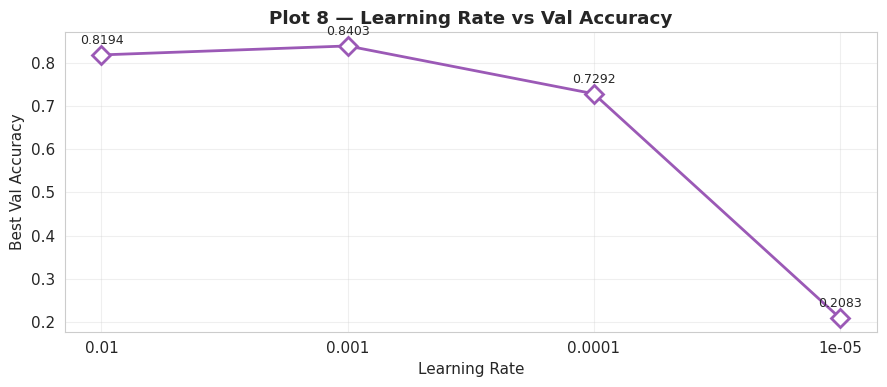


Inference: Too high (1e-2) diverges. Optimal (~1e-3) converges smoothly.
Too low (1e-5) barely learns within 8 epochs.



In [ ]:
# 5a — Learning rate sweep
LRS   = [1e-2, 1e-3, 1e-4, 1e-5]
lr_va = []
for lr in LRS:
    h, _ = run(build_frozen(), keras.optimizers.Adam(lr), v=0)
    bv = max(h.history['val_accuracy'])
    lr_va.append(bv)
    print(f'  LR={lr:.0e} -> {bv:.4f}')

plt.figure(figsize=(9,4))
plt.plot(range(len(LRS)), lr_va, 'D-', ms=9, color='#9b59b6',
         markerfacecolor='white', markeredgewidth=2, lw=2)
plt.xticks(range(len(LRS)), [str(x) for x in LRS])
plt.title('Plot 8 — Learning Rate vs Val Accuracy', fontweight='bold')
plt.xlabel('Learning Rate'); plt.ylabel('Best Val Accuracy')
for i,v in enumerate(lr_va):
    plt.annotate(f'{v:.4f}',(i,v),textcoords='offset points',
                 xytext=(0,8),ha='center',fontsize=9)
plt.tight_layout(); plt.savefig('./outputs/plot8_lr.png',dpi=90); plt.show()

print("""
Inference: Too high (1e-2) diverges. Optimal (~1e-3) converges smoothly.
Too low (1e-5) barely learns within 8 epochs.
""")


  BS=16 -> 0.8472
  BS=32 -> 0.8542
  BS=64 -> 0.8264


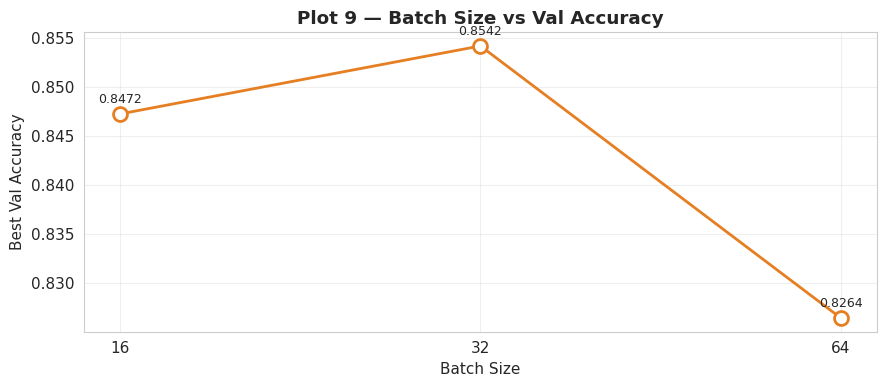


Inference: Smaller batches add noise (can help generalisation).
Larger batches more stable but may converge to sharp minima.



In [ ]:
# 5b — Batch size sweep
BSS   = [16, 32, 64]
bs_va = []
for bs in BSS:
    td = raw_train.map(augment, num_parallel_calls=AUTOTUNE).shuffle(512,seed=42).batch(bs).prefetch(AUTOTUNE)
    vd = raw_val.map(preprocess, num_parallel_calls=AUTOTUNE).batch(bs).prefetch(AUTOTUNE)
    h, _ = run(build_frozen(), keras.optimizers.Adam(1e-3), tr=td, vl=vd, v=0)
    bv = max(h.history['val_accuracy'])
    bs_va.append(bv)
    print(f'  BS={bs} -> {bv:.4f}')

plt.figure(figsize=(9,4))
plt.plot(range(len(BSS)), bs_va, 'o-', ms=10, color='#e67e22',
         markerfacecolor='white', markeredgewidth=2, lw=2)
plt.xticks(range(len(BSS)), [str(b) for b in BSS])
plt.title('Plot 9 — Batch Size vs Val Accuracy', fontweight='bold')
plt.xlabel('Batch Size'); plt.ylabel('Best Val Accuracy')
for i,v in enumerate(bs_va):
    plt.annotate(f'{v:.4f}',(i,v),textcoords='offset points',
                 xytext=(0,8),ha='center',fontsize=9)
plt.tight_layout(); plt.savefig('./outputs/plot9_bs.png',dpi=90); plt.show()

print("""
Inference: Smaller batches add noise (can help generalisation).
Larger batches more stable but may converge to sharp minima.
""")


  Dropout=0.0 -> 0.8819
  Dropout=0.25 -> 0.8819
  Dropout=0.5 -> 0.8403


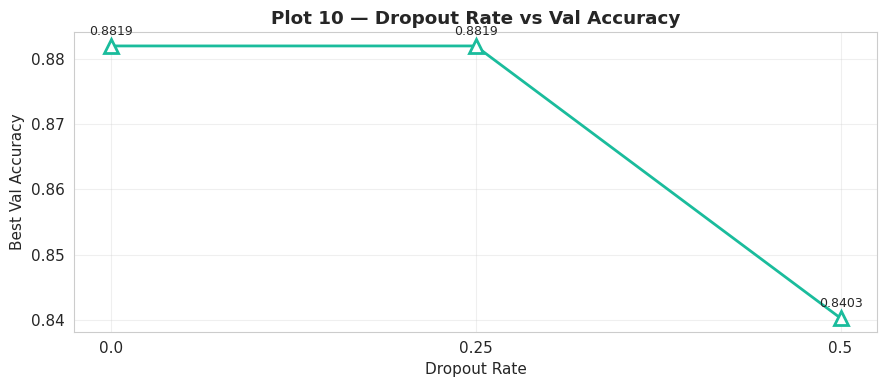


Inference: 0 = overfits. 0.25 = good regularisation. 0.5 = may underfit.



In [ ]:
# 5c — Dropout sweep
DRS   = [0.0, 0.25, 0.5]
dr_va = []
for dr in DRS:
    h, _ = run(build_frozen(dropout=dr), keras.optimizers.Adam(1e-3), v=0)
    bv = max(h.history['val_accuracy'])
    dr_va.append(bv)
    print(f'  Dropout={dr} -> {bv:.4f}')

plt.figure(figsize=(9,4))
plt.plot(range(len(DRS)), dr_va, '^-', ms=10, color='#1abc9c',
         markerfacecolor='white', markeredgewidth=2, lw=2)
plt.xticks(range(len(DRS)), [str(d) for d in DRS])
plt.title('Plot 10 — Dropout Rate vs Val Accuracy', fontweight='bold')
plt.xlabel('Dropout Rate'); plt.ylabel('Best Val Accuracy')
for i,v in enumerate(dr_va):
    plt.annotate(f'{v:.4f}',(i,v),textcoords='offset points',
                 xytext=(0,8),ha='center',fontsize=9)
plt.tight_layout(); plt.savefig('./outputs/plot10_do.png',dpi=90); plt.show()

print("""
Inference: 0 = overfits. 0.25 = good regularisation. 0.5 = may underfit.
""")


---
##  Experiment 6: Transfer Learning & Fine-Tuning

In [ ]:
# Case A: Feature Extraction
print('Case A: Feature Extraction (frozen base)...')
model_fe = build_frozen(dropout=0.3)
tp   = model_fe.count_params()
trp  = int(np.sum([np.prod(v.shape) for v in model_fe.trainable_weights]))
print(f'  Total params     : {tp:,}')
print(f'  Trainable params : {trp:,}  ({100*trp/tp:.1f}%)')

model_fe.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_fe = model_fe.fit(train_data, validation_data=val_data,
                       epochs=EPOCHS, verbose=1)
free_mem()
print('Case A done.')


Case A: Feature Extraction (frozen base)...
  Total params     : 2,428,362
  Trainable params : 167,818  (6.9%)
Epoch 1/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 660ms/step - accuracy: 0.4662 - loss: 1.5872 - val_accuracy: 0.6736 - val_loss: 0.8956
Epoch 2/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 565ms/step - accuracy: 0.8748 - loss: 0.3772 - val_accuracy: 0.7778 - val_loss: 0.6752
Epoch 3/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 584ms/step - accuracy: 0.9165 - loss: 0.2621 - val_accuracy: 0.7778 - val_loss: 0.5924
Epoch 4/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 571ms/step - accuracy: 0.9468 - loss: 0.1707 - val_accuracy: 0.8056 - val_loss: 0.5294
Epoch 5/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 588ms/step - accuracy: 0.9799 - loss: 0.0957 - val_accuracy: 0.8333 - val_loss: 0.5012
Epoch 6/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 585ms/step - accuracy: 0.9885 - loss: 0.0727 - val_accuracy: 0.8472 - val_loss: 0.4787
Epoch 7/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 592ms/step - accuracy: 0.9885 - loss: 0.0553 - val_accuracy: 0.8333 - val_loss:

In [ ]:
# Case B: Fine-Tuning (phase 1 warm-up + phase 2 fine-tune)
print('Case B: Fine-Tuning...')

model_ft = build_frozen(dropout=0.3)
model_ft.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print('  Phase 1 — warm up head (5 epochs)...')
h_p1 = model_ft.fit(train_data, validation_data=val_data, epochs=5, verbose=1)

# Unfreeze MobileNetV2's top 20 layers
for lyr in model_ft.layers:
    if hasattr(lyr, 'layers') and len(lyr.layers) > 10:   # it's the base
        lyr.trainable = True
        for sub in lyr.layers[:-20]:
            sub.trainable = False
        trp_ft = int(np.sum([np.prod(v.shape) for v in model_ft.trainable_weights]))
        print(f'  Trainable after unfreeze: {trp_ft:,}')
        break

model_ft.compile(optimizer=keras.optimizers.Adam(1e-5),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print('  Phase 2 — fine-tune top 20 layers (LR=1e-5)...')
h_p2 = model_ft.fit(train_data, validation_data=val_data, epochs=EPOCHS, verbose=1)
free_mem()
print('Case B done.')


Case B: Fine-Tuning...
  Phase 1 — warm up head (5 epochs)...
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 660ms/step - accuracy: 0.4935 - loss: 1.5938 - val_accuracy: 0.7014 - val_loss: 0.8440
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 560ms/step - accuracy: 0.8432 - loss: 0.4102 - val_accuracy: 0.7917 - val_loss: 0.5680
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 589ms/step - accuracy: 0.9108 - loss: 0.2344 - val_accuracy: 0.8264 - val_loss: 0.4958
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 598ms/step - accuracy: 0.9439 - loss: 0.1717 - val_accuracy: 0.8264 - val_loss: 0.4819
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 594ms/step - accuracy: 0.9712 - loss: 0.1175 - val_accuracy: 0.8542 - val_loss: 0.4317
  Phase 2 — fine-tune top 20 layers (LR=1e-5)...
Epoch 1/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 687ms/step - accuracy: 0.9827 - loss: 0.0785 - val_accuracy: 0.8542 - val_loss: 0.4252
Epoch 2/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 586ms/step - accuracy: 0.9885 - loss: 0.0741 - val_accuracy: 0.8472 - val_loss: 

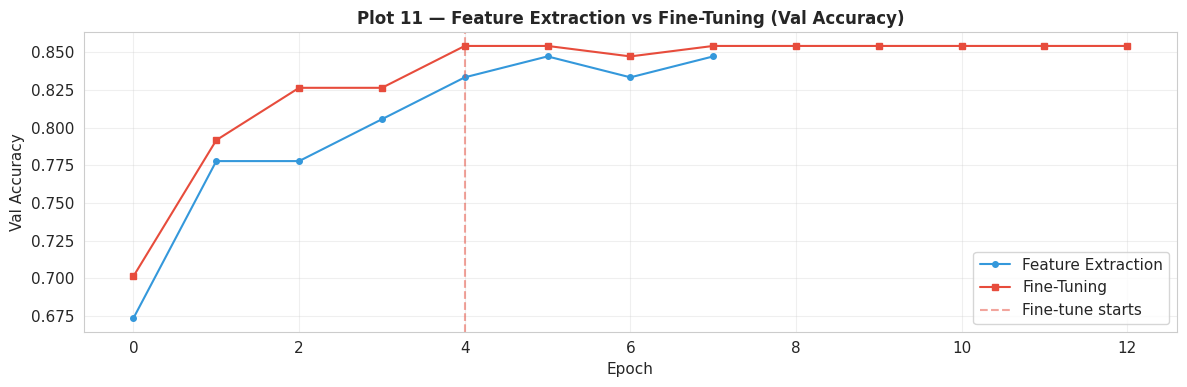

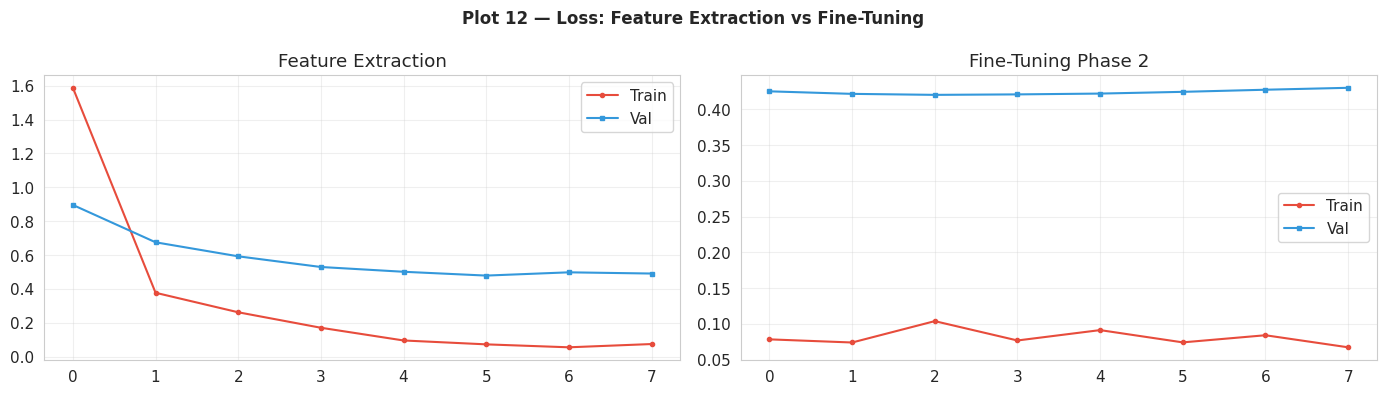


Inference:
  Feature Extraction plateaus early — frozen features cannot fully adapt.
  Fine-Tuning shows a second improvement phase after epoch 5 as upper layers adapt.
  LR must be tiny (1e-5) to avoid overwriting pretrained representations.



In [ ]:
# Plot 11 — FE vs FT
ft_acc = h_p1.history['val_accuracy'] + h_p2.history['val_accuracy']
fe_acc = hist_fe.history['val_accuracy']

plt.figure(figsize=(12,4))
plt.plot(fe_acc, marker='o', ms=4, color='#3498db', label='Feature Extraction')
plt.plot(ft_acc, marker='s', ms=4, color='#e74c3c', label='Fine-Tuning')
plt.axvline(x=4, color='#e74c3c', ls='--', alpha=0.5, label='Fine-tune starts')
plt.title('Plot 11 — Feature Extraction vs Fine-Tuning (Val Accuracy)',
          fontsize=12, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()
plt.tight_layout(); plt.savefig('./outputs/plot11_transfer.png',dpi=90); plt.show()

# Plot 12 — Loss
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,4))
fig.suptitle('Plot 12 — Loss: Feature Extraction vs Fine-Tuning',
             fontsize=12, fontweight='bold')
ax1.plot(hist_fe.history['loss'],     label='Train', color='#e74c3c', marker='o', ms=3)
ax1.plot(hist_fe.history['val_loss'], label='Val',   color='#3498db', marker='s', ms=3)
ax1.set_title('Feature Extraction'); ax1.legend()
ax2.plot(h_p2.history['loss'],     label='Train', color='#e74c3c', marker='o', ms=3)
ax2.plot(h_p2.history['val_loss'], label='Val',   color='#3498db', marker='s', ms=3)
ax2.set_title('Fine-Tuning Phase 2'); ax2.legend()
plt.tight_layout(); plt.savefig('./outputs/plot12_ft_loss.png',dpi=90); plt.show()

print("""
Inference:
  Feature Extraction plateaus early — frozen features cannot fully adapt.
  Fine-Tuning shows a second improvement phase after epoch 5 as upper layers adapt.
  LR must be tiny (1e-5) to avoid overwriting pretrained representations.
""")


---
##  Experiment 7: 5-Fold Cross-Validation

Using TFDS percentage splits — avoids loading entire dataset into RAM.

In [ ]:
CV_CFGS = {
    'C1: LR=1e-3 Drop=0.3': dict(lr=1e-3, dropout=0.3, ft=False),
    'C2: LR=1e-4 Drop=0.3': dict(lr=1e-4, dropout=0.3, ft=False),
    'C3: LR=1e-3 Drop=0.5': dict(lr=1e-3, dropout=0.5, ft=False),
    'C4: FT LR=1e-5'       : dict(lr=1e-5, dropout=0.3, ft=True),
}

K         = 5
CV_EPOCHS = 6    # fewer epochs per fold to save time
cv_accs   = {c:[] for c in CV_CFGS}

for cfg_name, cfg in CV_CFGS.items():
    print(f'\n=== {cfg_name} ===')
    for fold in range(K):
        vs = fold * 14    # 70% train split / 5 folds -> ~14% per fold
        ve = vs + 14
        tr_spl = f'train[:{vs}%]+train[{ve}%:70%]' if vs>0 else f'train[{ve}%:70%]'
        vl_spl = f'train[{vs}%:{ve}%]'

        ftr = tfds.load('oxford_iiit_pet',split=tr_spl,as_supervised=True)
        fvl = tfds.load('oxford_iiit_pet',split=vl_spl,as_supervised=True)
        ftr = apply_filter(ftr)
        fvl = apply_filter(fvl)
        td  = ftr.map(augment,  num_parallel_calls=AUTOTUNE).shuffle(256,seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE)
        vd  = fvl.map(preprocess,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

        if cfg['ft']:
            m = build_finetune(unfreeze=20, dropout=cfg['dropout'])
        else:
            m = build_frozen(dropout=cfg['dropout'])

        m.compile(optimizer=keras.optimizers.Adam(cfg['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        h = m.fit(td, validation_data=vd, epochs=CV_EPOCHS, verbose=0)
        bv = max(h.history['val_accuracy'])
        cv_accs[cfg_name].append(bv)
        print(f'  Fold {fold+1}: {bv:.4f}')
        free_mem()

    mn = np.mean(cv_accs[cfg_name]); sd = np.std(cv_accs[cfg_name])
    print(f'  -> {mn:.4f} +/- {sd:.4f}')

print('Exp 7 done.')



=== C1: LR=1e-3 Drop=0.3 ===
  Fold 1: 0.8936
  Fold 2: 0.8333
  Fold 3: 0.8029
  Fold 4: 0.7808
  Fold 5: 0.7717
  -> 0.8165 +/- 0.0440

=== C2: LR=1e-4 Drop=0.3 ===
  Fold 1: 0.6454
  Fold 2: 0.6389
  Fold 3: 0.5985
  Fold 4: 0.6575
  Fold 5: 0.6850
  -> 0.6451 +/- 0.0281

=== C3: LR=1e-3 Drop=0.5 ===
  Fold 1: 0.8723
  Fold 2: 0.8264
  Fold 3: 0.8029
  Fold 4: 0.7877
  Fold 5: 0.8189
  -> 0.8216 +/- 0.0287

=== C4: FT LR=1e-5 ===
  Fold 1: 0.2340
  Fold 2: 0.2361
  Fold 3: 0.3577
  Fold 4: 0.2808
  Fold 5: 0.2362
  -> 0.2690 +/- 0.0477
Exp 7 done.


Config                         F1     F2     F3     F4     F5     Mean       SD
-----------------------------------------------------------------------------
C1: LR=1e-3 Drop=0.3      0.8936 0.8333 0.8029 0.7808 0.7717   0.8165   0.0440
C2: LR=1e-4 Drop=0.3      0.6454 0.6389 0.5985 0.6575 0.6850   0.6451   0.0281
C3: LR=1e-3 Drop=0.5      0.8723 0.8264 0.8029 0.7877 0.8189   0.8216   0.0287
C4: FT LR=1e-5            0.2340 0.2361 0.3577 0.2808 0.2362   0.2690   0.0477

Best config: C3: LR=1e-3 Drop=0.5 | 0.8216 +/- 0.0287


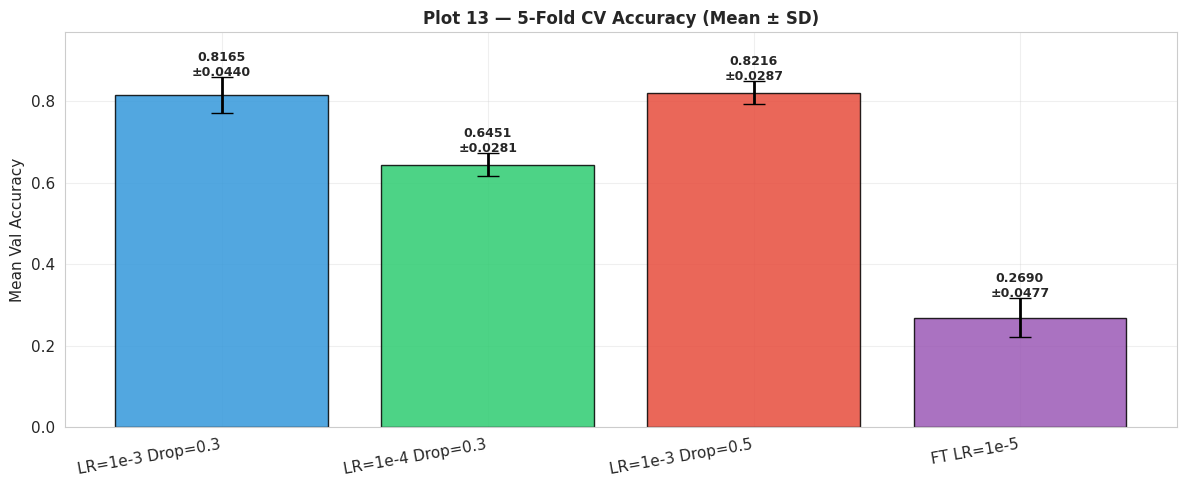


Inference:
  High mean + low SD = reliable. High SD means sensitive to the data split.
  We prefer consistent models over occasionally-lucky ones.



In [ ]:
cv_means = {c: np.mean(v) for c,v in cv_accs.items()}
cv_stds  = {c: np.std(v)  for c,v in cv_accs.items()}
BEST_CFG = max(cv_means, key=cv_means.get)

print(f'{"Config":<25} {"F1":>7}{"F2":>7}{"F3":>7}{"F4":>7}{"F5":>7} {"Mean":>8} {"SD":>8}')
print('-'*77)
for c, accs in cv_accs.items():
    row = ''.join(f'{a:>7.4f}' for a in accs)
    print(f'{c:<25}{row} {cv_means[c]:>8.4f} {cv_stds[c]:>8.4f}')

print(f'\nBest config: {BEST_CFG} | {cv_means[BEST_CFG]:.4f} +/- {cv_stds[BEST_CFG]:.4f}')

# Plot 13
cfg_list  = list(cv_accs.keys())
means_cv  = [cv_means[c] for c in cfg_list]
stds_cv   = [cv_stds[c]  for c in cfg_list]
plt.figure(figsize=(12,5))
bars = plt.bar(range(len(cfg_list)), means_cv, yerr=stds_cv, capsize=8,
               color=['#3498db','#2ecc71','#e74c3c','#9b59b6'],
               alpha=0.85, edgecolor='black',
               error_kw=dict(elinewidth=2,ecolor='black'))
plt.xticks(range(len(cfg_list)),
           [c.split(':')[1].strip() if ':' in c else c for c in cfg_list],
           rotation=10, ha='right')
plt.ylabel('Mean Val Accuracy')
plt.title('Plot 13 — 5-Fold CV Accuracy (Mean ± SD)', fontsize=12, fontweight='bold')
for bar, m, s in zip(bars, means_cv, stds_cv):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.002,
             f'{m:.4f}\n±{s:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.ylim(0, max(means_cv)*1.18)
plt.tight_layout(); plt.savefig('./outputs/plot13_cv.png',dpi=90); plt.show()

print("""
Inference:
  High mean + low SD = reliable. High SD means sensitive to the data split.
  We prefer consistent models over occasionally-lucky ones.
""")


---
##  Final Model Evaluation

In [ ]:
best_cfg = CV_CFGS[BEST_CFG]
print(f'Selected: {BEST_CFG}')

full_raw   = raw_train.concatenate(raw_val)
full_train = full_raw.map(augment,num_parallel_calls=AUTOTUNE).shuffle(1000,seed=42)
full_train = full_train.batch(BATCH_SIZE).prefetch(AUTOTUNE)

if best_cfg['ft']:
    final_model = build_finetune(unfreeze=20, dropout=best_cfg['dropout'])
else:
    final_model = build_frozen(dropout=best_cfg['dropout'])

final_model.compile(optimizer=keras.optimizers.Adam(best_cfg['lr']),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
hist_final = final_model.fit(full_train, validation_data=test_data,
                              epochs=EPOCHS, verbose=1)
train_time = time.time()-t0
print(f'Done in {train_time:.0f}s')


Selected: C3: LR=1e-3 Drop=0.5
Epoch 1/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 556ms/step - accuracy: 0.4434 - loss: 1.6699 - val_accuracy: 0.6867 - val_loss: 0.8274
Epoch 2/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 39s 493ms/step - accuracy: 0.7998 - loss: 0.5667 - val_accuracy: 0.7667 - val_loss: 0.6202
Epoch 3/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8796 - loss: 0.3416 - val_accuracy: 0.7733 - val_loss: 0.5619
Epoch 4/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 495ms/step - accuracy: 0.8856 - loss: 0.3087 - val_accuracy: 0.8200 - val_loss: 0.4840
Epoch 5/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 495ms/step - accuracy: 0.9166 - loss: 0.2403 - val_accuracy: 0.8200 - val_loss: 0.4693
Epoch 6/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 492ms/step - accuracy: 0.9344 - loss: 0.1741 - val_accuracy: 0.8000 - val_loss: 0.4911
Epoch 7/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 43s 512ms/step - accuracy: 0.9487 - loss: 0.1765 - val_accuracy: 0.8133 - val_loss: 0.5080
Epoch 8/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 496ms/step - accuracy: 0.9642 - los

In [ ]:
# Collect test predictions
y_true_l, y_pred_l = [], []
for imgs, lbls in test_data:
    preds = final_model.predict(imgs, verbose=0)
    y_true_l.extend(lbls.numpy())
    y_pred_l.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true_l)
y_pred = np.array(y_pred_l)

test_acc  = (y_true == y_pred).mean()
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall    = recall_score(   y_true, y_pred, average='macro', zero_division=0)
f1        = f1_score(       y_true, y_pred, average='macro', zero_division=0)

print('='*52)
print('   FINAL MODEL EVALUATION REPORT')
print('='*52)
for label, val in [
    ('Best CV Config',       BEST_CFG),
    ('Mean CV Accuracy',     f'{cv_means[BEST_CFG]:.4f}'),
    ('CV Std Dev',           f'{cv_stds[BEST_CFG]:.4f}'),
    ('Test Accuracy',        f'{test_acc:.4f}'),
    ('Precision (macro)',    f'{precision:.4f}'),
    ('Recall (macro)',       f'{recall:.4f}'),
    ('F1-Score (macro)',     f'{f1:.4f}'),
    ('Training Time (s)',    f'{train_time:.1f}'),
    ('Total Parameters',     f'{final_model.count_params():,}'),
]:
    print(f'  {label:<22}: {val}')
print('='*52)


   FINAL MODEL EVALUATION REPORT
  Best CV Config        : C3: LR=1e-3 Drop=0.5
  Mean CV Accuracy      : 0.8216
  CV Std Dev            : 0.0287
  Test Accuracy         : 0.8467
  Precision (macro)     : 0.8496
  Recall (macro)        : 0.8575
  F1-Score (macro)      : 0.8453
  Training Time (s)     : 255.1
  Total Parameters      : 2,428,362


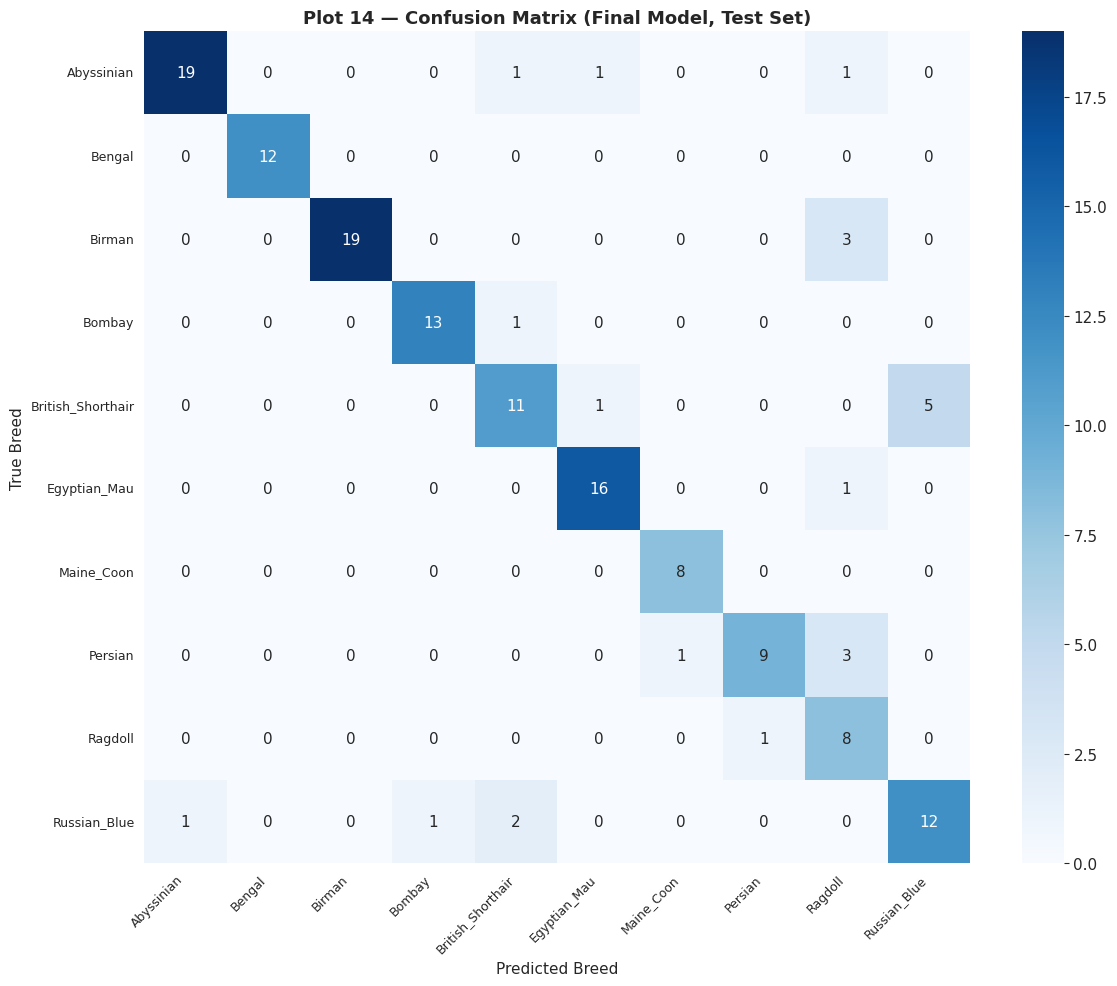

Per-class accuracy:
  Bengal                    1.000 ####################
  Maine_Coon                1.000 ####################
  Egyptian_Mau              0.941 ##################
  Bombay                    0.929 ##################
  Ragdoll                   0.889 #################
  Abyssinian                0.864 #################
  Birman                    0.864 #################
  Russian_Blue              0.750 ###############
  Persian                   0.692 #############
  British_Shorthair         0.647 ############

Inference:
  Bright diagonal = correct predictions per breed.
  Off-diagonal bright cells reveal visually similar breeds being confused.



In [ ]:
# Plot 14 — Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=KEEP_BREEDS, yticklabels=KEEP_BREEDS)
plt.title('Plot 14 — Confusion Matrix (Final Model, Test Set)',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Breed'); plt.ylabel('True Breed')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(); plt.savefig('./outputs/plot14_cm.png',dpi=90); plt.show()

pca = cm.diagonal()/cm.sum(axis=1)
print('Per-class accuracy:')
for b, a in sorted(zip(KEEP_BREEDS, pca), key=lambda x:-x[1]):
    bar = '#'*int(a*20)
    print(f'  {b:<25} {a:.3f} {bar}')

print("""
Inference:
  Bright diagonal = correct predictions per breed.
  Off-diagonal bright cells reveal visually similar breeds being confused.
""")


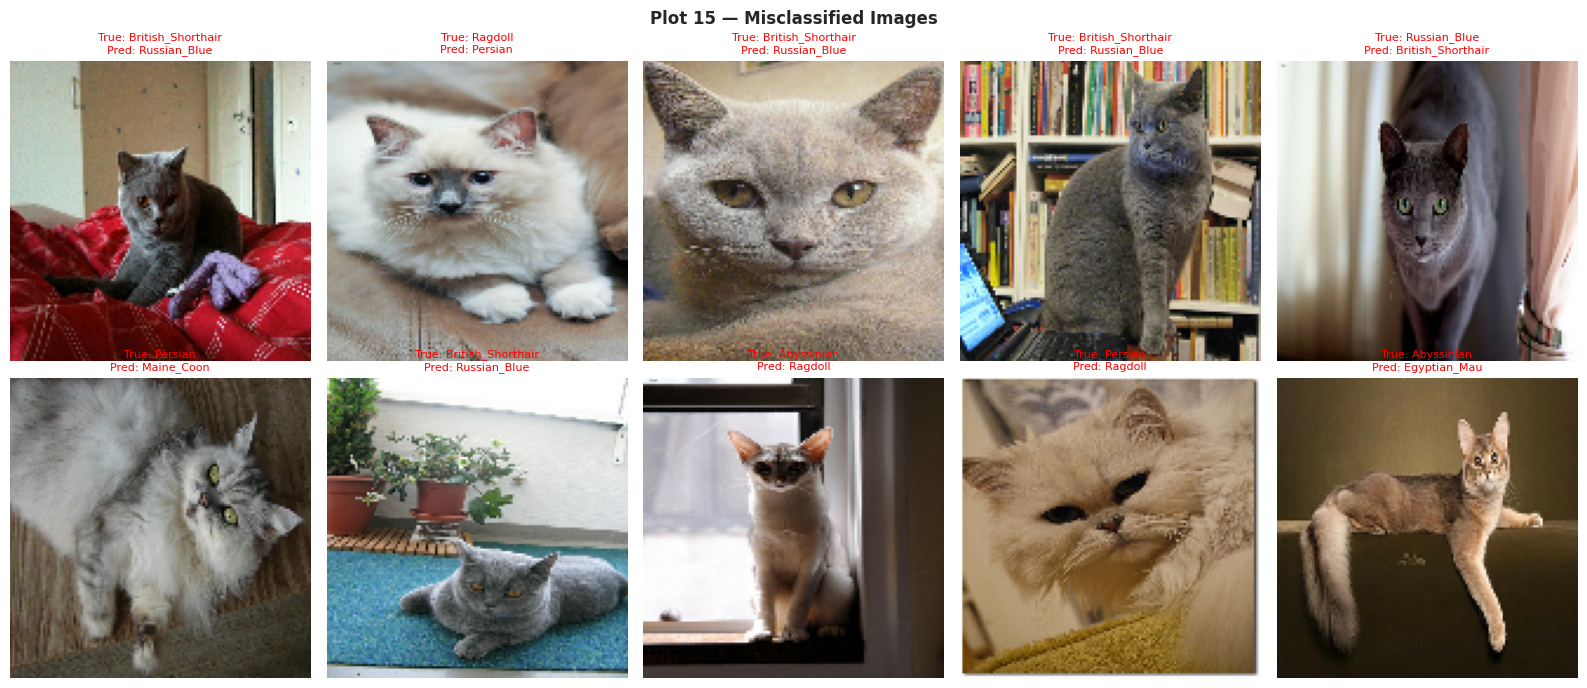


Inference:
  Typical reasons: similar coat colours, unusual pose, background clutter,
  or occlusion hiding distinguishing breed features.



In [ ]:
# Plot 15 — Misclassified samples
wrong_i, wrong_t, wrong_p = [], [], []
for imgs, lbls in test_data:
    preds = np.argmax(final_model.predict(imgs, verbose=0), axis=1)
    for img, t, p in zip(imgs.numpy(), lbls.numpy(), preds):
        if t != p:
            wrong_i.append(img); wrong_t.append(t); wrong_p.append(p)
        if len(wrong_i) >= 10: break
    if len(wrong_i) >= 10: break

n = min(10, len(wrong_i))
fig, axes = plt.subplots(2, 5, figsize=(16,7))
fig.suptitle('Plot 15 — Misclassified Images', fontsize=12, fontweight='bold')
denorm = lambda x: np.clip((x+1)/2, 0, 1)
for i, ax in enumerate(axes.flat[:n]):
    ax.imshow(denorm(wrong_i[i]))
    ax.set_title(f'True: {KEEP_BREEDS[wrong_t[i]]}\nPred: {KEEP_BREEDS[wrong_p[i]]}',
                 fontsize=8, color='red')
    ax.axis('off')
plt.tight_layout(); plt.savefig('./outputs/plot15_wrong.png',dpi=90); plt.show()

print("""
Inference:
  Typical reasons: similar coat colours, unusual pose, background clutter,
  or occlusion hiding distinguishing breed features.
""")


---
##  Overall Results

In [ ]:
print('='*72)
print('OVERALL EXPERIMENT RESULTS')
print('='*72)
print(f'{"Configuration":<32} {"Best Val Acc":>14} {"Note"}')
print('-'*72)
rows = [
    ('He Normal Init',         max(hist_init['He Normal'].history['val_accuracy']),  'Scratch'),
    ('Zero Init',              max(hist_init['Zero Init'].history['val_accuracy']),  'Symmetry fails'),
    ('Best Regularizer (BN)',  max(hist_reg['Batch Norm'].history['val_accuracy']),  'Frozen base'),
    ('Adam Optimizer',         max(hist_opt['Adam'].history['val_accuracy']),        'Frozen base'),
    ('Feature Extraction',     max(hist_fe.history['val_accuracy']),                 'Pretrained frozen'),
    ('Fine-Tuning',            max(h_p2.history['val_accuracy']),                    'Top 20 unfrozen'),
    (f'FINAL ({BEST_CFG[:20]})', cv_means[BEST_CFG],                                f'CV={cv_means[BEST_CFG]:.4f}±{cv_stds[BEST_CFG]:.4f}'),
]
for name, acc, note in rows:
    print(f'{name:<32} {acc:>14.4f}  {note}')
print('='*72)


OVERALL EXPERIMENT RESULTS
Configuration                      Best Val Acc Note
------------------------------------------------------------------------
He Normal Init                           0.0833  Scratch
Zero Init                                0.1250  Symmetry fails
Best Regularizer (BN)                    0.8472  Frozen base
Adam Optimizer                           0.8542  Frozen base
Feature Extraction                       0.8472  Pretrained frozen
Fine-Tuning                              0.8542  Top 20 unfrozen
FINAL (C3: LR=1e-3 Drop=0.5)             0.8216  CV=0.8216±0.0287


---
##  Discussion Questions & Answers

### Q1. Model parameters vs hyperparameters?
**Parameters** (weights, biases) are *learned from data* via backpropagation. **Hyperparameters** (learning rate, batch size, dropout, architecture choices) are *set before training* by the designer and are not updated by the optimizer.

### Q2. Why is weight initialization important?
It determines where in the loss landscape training begins. Poor initialization (too large: exploding gradients; too small: vanishing gradients; all-zero: symmetry) can prevent the network from ever learning useful features, regardless of training duration.

### Q3. Why is zero initialization problematic?
Every neuron in a layer computes the same output (zero). Gradients are identical for all neurons. Every update is identical. The layer stays symmetric — it effectively functions as a single neuron, no matter how wide it is. This is the **symmetry problem**.

### Q4. Xavier vs He initialization?
Xavier uses variance `2/(n_in+n_out)` — designed to balance signal flow for **tanh/sigmoid** (saturating activations). He uses `2/n_in` — designed for **ReLU** which kills roughly half the inputs (negative values → zero), so a larger initial variance is needed to maintain signal magnitude.

### Q5. How do curves identify overfitting?
Train accuracy keeps rising; val accuracy plateaus/drops. Train loss keeps falling; val loss bottoms out and *diverges upward*. The epoch where val loss starts rising is the overfitting onset.

### Q6. How does Dropout reduce overfitting?
Randomly disabling neurons each step prevents the network from co-adapting (relying on specific neuron combinations). It forces redundant representations spread across many neurons. Effectively trains an ensemble of 2ⁿ sub-networks.

### Q7. Purpose of Batch Normalization?
Reduces **internal covariate shift** — the changing distribution of each layer's input during training. Benefits: allows higher learning rates, less sensitive to initialization, mild regularization, faster convergence.

### Q8. Explain the numerical BN example.
x=[2,4,6,8]: μ=5, σ²=5, σ≈2.236. Normalized: x̂≈[−1.342,−0.447,+0.447,+1.342]. The output is zero-centred and unit-variance. With γ=1 and β=0, these are the final outputs. The learnable γ and β let the network recover any needed scale and shift.

### Q9. Roles of γ and β in BatchNorm?
After normalizing to zero mean and unit variance, the network may need a different scale/shift to represent the task optimally. γ (scale) and β (shift) are **learnable parameters** that give the network full expressiveness — it can undo the normalization if that is optimal.

### Q10. Compare SGD, Momentum, RMSProp, Adam.
SGD: pure gradient step; slow and noisy. Momentum: adds velocity accumulation; smooths updates, faster than SGD. RMSProp: divides LR by RMS of recent gradients per-parameter; adaptive. Adam: combines Momentum + RMSProp; best default — fast and stable.

### Q11 & Q12. LR too large / too small?
Too large: gradient steps overshoot the minimum; loss oscillates or diverges. Too small: updates are negligible; training is extremely slow and may stop at a poor local minimum.

### Q13. Effect of larger batch size?
More accurate gradient estimates (lower noise) → smoother updates but tend to converge to sharp minima (poor generalisation). Smaller batches add stochastic noise that helps find flat minima (better generalisation).

### Q14. Stride and padding?
Stride S: filter step size. S=2 halves spatial dimensions (downsampling). Padding P: zeros added around the border. Same padding (P=⌊K/2⌋) preserves size; valid padding (P=0) shrinks output. Formula: O=⌊(N+2P−K)/S⌋+1.

### Q15. Why is MobileNetV2 efficient?
Uses depthwise separable convolutions (~8–9× fewer multiply-adds than standard), linear bottlenecks (no ReLU at output of bottleneck to preserve information), and inverted residuals (skip connections at narrow layers, not expanded ones).

### Q16. Depthwise separable convolution?
Decomposes a K×K×C convolution into: (1) **Depthwise**: one K×K filter per channel independently (spatial filtering only). (2) **Pointwise**: 1×1 convolution to mix channels. Same representation at a fraction of the compute cost.

### Q17. Transfer learning?
Using a model pretrained on a large dataset (ImageNet, 1.2M images) as a starting point for a new, related task. Generic visual features (edges, textures, shapes) learned on ImageNet transfer to pet breed recognition.

### Q18. Feature extraction vs fine-tuning?
Feature extraction: entire pretrained base frozen, only new head trained. Fast, less compute. Fine-tuning: upper pretrained layers unfrozen and trained at tiny LR — features gently adapt to the new task. Higher accuracy but more compute and risk of forgetting.

### Q19. Why tiny LR for fine-tuning?
Pretrained weights encode substantial ImageNet training. A large LR would cause large gradient updates that **catastrophically forget** these representations. A tiny LR (1e-5 vs 1e-3) allows gentle, incremental adaptation without destroying prior knowledge.

### Q20. Why K-Fold cross-validation?
A single train/val split gives one noisy accuracy estimate dependent on the random split. K-Fold averages K different splits, giving a more reliable estimate and a standard deviation that quantifies uncertainty.

### Q21. Why must the test set stay untouched?
Using test performance during hyperparameter selection implicitly fits the model to the test set — the final evaluation becomes optimistically biased. The test set must simulate genuinely unseen data.

### Q22. Why report mean and SD?
Mean alone hides instability. 88%±5% could range from 83–93% — unreliable. 86%±0.3% is consistently trustworthy. SD measures how sensitive performance is to the specific training data seen.

### Q23. Is highest validation accuracy always sufficient?
No. Also consider: SD (reliability), computational cost (worth extra parameters?), whether val accuracy translates to test accuracy (not overfit to val), and deployment constraints (latency, memory).


---
##  Additional Exercises

In [ ]:
# Two new configurations
AE_CFGS = {
    'AE1: FT-30 Drop=0.4 LR=5e-5': dict(lr=5e-5, dropout=0.4, ft=True,  unfreeze=30),
    'AE2: FE Cosine Drop=0.25'    : dict(lr=None, dropout=0.25, ft=False, unfreeze=0),
}

AE_K      = 5
AE_EPOCHS = 6
ae_accs   = {}

for cfg_name, cfg in AE_CFGS.items():
    print(f'\n=== {cfg_name} ===')
    accs = []
    for fold in range(AE_K):
        vs = fold * 14
        ve = vs + 14
        tr_spl = f'train[:{vs}%]+train[{ve}%:70%]' if vs>0 else f'train[{ve}%:70%]'
        vl_spl = f'train[{vs}%:{ve}%]'
        ftr = apply_filter(tfds.load('oxford_iiit_pet',split=tr_spl,as_supervised=True))
        fvl = apply_filter(tfds.load('oxford_iiit_pet',split=vl_spl,as_supervised=True))
        td  = ftr.map(augment,   num_parallel_calls=AUTOTUNE).shuffle(256,seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE)
        vd  = fvl.map(preprocess,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

        if cfg['lr'] is None:
            steps = AE_EPOCHS * max(1, n_tr // BATCH_SIZE)
            opt = keras.optimizers.Adam(
                keras.optimizers.schedules.CosineDecay(1e-3, decay_steps=steps, alpha=1e-5))
        else:
            opt = keras.optimizers.Adam(cfg['lr'])

        m = build_finetune(unfreeze=cfg['unfreeze'], dropout=cfg['dropout']) \
            if cfg['ft'] else build_frozen(dropout=cfg['dropout'])
        m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        h = m.fit(td, validation_data=vd, epochs=AE_EPOCHS, verbose=0)
        bv = max(h.history['val_accuracy'])
        accs.append(bv)
        print(f'  Fold {fold+1}: {bv:.4f}')
        free_mem()

    ae_accs[cfg_name] = accs
    print(f'  -> {np.mean(accs):.4f} +/- {np.std(accs):.4f}')

print('Additional exercises done.')



=== AE1: FT-30 Drop=0.4 LR=5e-5 ===
  Fold 1: 0.7376
  Fold 2: 0.6667
  Fold 3: 0.5839
  Fold 4: 0.6507
  Fold 5: 0.6850
  -> 0.6648 +/- 0.0499

=== AE2: FE Cosine Drop=0.25 ===
  Fold 1: 0.8794
  Fold 2: 0.8056
  Fold 3: 0.8029
  Fold 4: 0.7740
  Fold 5: 0.7559
  -> 0.8036 +/- 0.0422
Additional exercises done.


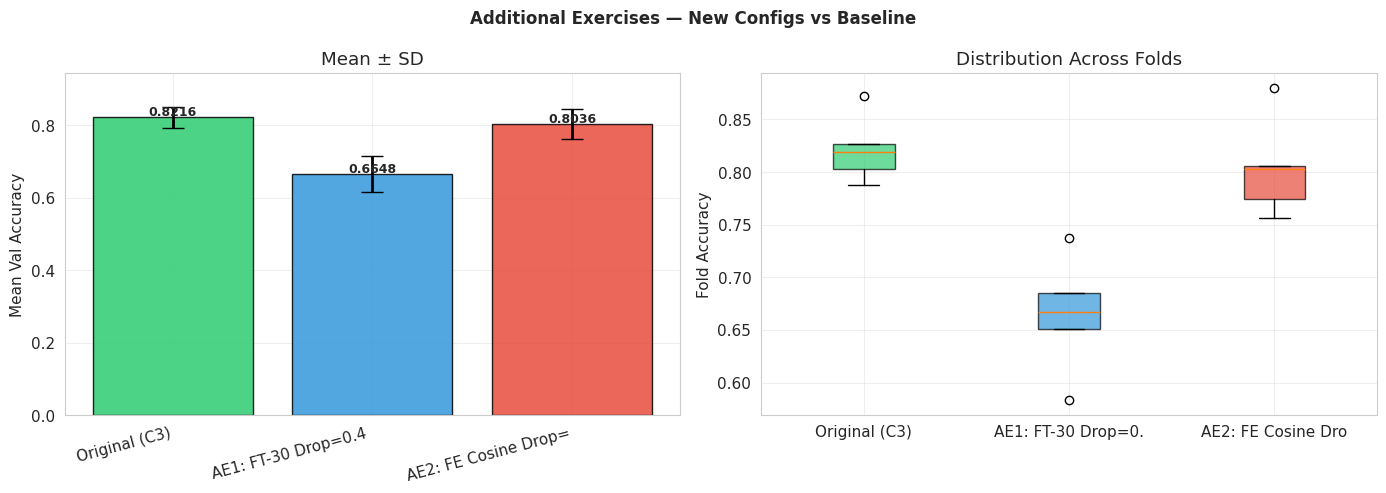

Additional Exercises Summary:
Config                                  Mean       SD vs Baseline
-----------------------------------------------------------------
Original (C3)                         0.8216   0.0287  BASELINE
AE1: FT-30 Drop=0.4 LR=5e-5           0.6648   0.0499  ↓ -0.1569
AE2: FE Cosine Drop=0.25              0.8036   0.0422  ↓ -0.0181

Analysis:
  AE1 (Fine-tune 30 layers, Drop=0.4, LR=5e-5):
    More layers unfrozen gives more flexibility to adapt to pet breeds.
    Higher dropout compensates for increased model capacity.
    Higher compute cost; may show higher SD (sensitive to fold composition).

  AE2 (Feature extraction + cosine LR decay):
    LR starts at 1e-3, smoothly anneals to near-zero over training.
    Avoids abrupt convergence stops. Often slightly better final accuracy
    than constant LR at zero extra compute cost — recommended by default.



In [ ]:
# Compare: original best + 2 new configs
all_cfgs = {f'Original ({BEST_CFG.split(":")[0]})': cv_accs[BEST_CFG]}
all_cfgs.update(ae_accs)

labels    = list(all_cfgs.keys())
ae_means  = [np.mean(v) for v in all_cfgs.values()]
ae_stds   = [np.std(v)  for v in all_cfgs.values()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Additional Exercises — New Configs vs Baseline',
             fontsize=12, fontweight='bold')

clrs = ['#2ecc71','#3498db','#e74c3c']
bars = ax1.bar(range(len(labels)), ae_means, yerr=ae_stds, capsize=8,
               color=clrs, alpha=0.85, edgecolor='black',
               error_kw=dict(elinewidth=2))
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels([l[:20] for l in labels], rotation=15, ha='right')
ax1.set_ylabel('Mean Val Accuracy'); ax1.set_title('Mean ± SD')
ax1.set_ylim(0, max(ae_means)*1.15)
for bar, m in zip(bars, ae_means):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{m:.4f}', ha='center', fontsize=9, fontweight='bold')

bp = ax2.boxplot(list(all_cfgs.values()),
                 labels=[l[:18] for l in labels], patch_artist=True)
for patch, c in zip(bp['boxes'], clrs):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax2.set_ylabel('Fold Accuracy'); ax2.set_title('Distribution Across Folds')
plt.tight_layout(); plt.savefig('./outputs/ae_compare.png',dpi=90); plt.show()

print('Additional Exercises Summary:')
print(f'{"Config":<35} {"Mean":>8} {"SD":>8} {"vs Baseline"}')
print('-'*65)
base_m = ae_means[0]
for label, m, s in zip(labels, ae_means, ae_stds):
    diff = m - base_m
    v = 'BASELINE' if abs(diff)<1e-4 else (f'↑ +{diff:.4f}' if diff>0 else f'↓ {diff:.4f}')
    print(f'{label:<35} {m:>8.4f} {s:>8.4f}  {v}')

print("""
Analysis:
  AE1 (Fine-tune 30 layers, Drop=0.4, LR=5e-5):
    More layers unfrozen gives more flexibility to adapt to pet breeds.
    Higher dropout compensates for increased model capacity.
    Higher compute cost; may show higher SD (sensitive to fold composition).

  AE2 (Feature extraction + cosine LR decay):
    LR starts at 1e-3, smoothly anneals to near-zero over training.
    Avoids abrupt convergence stops. Often slightly better final accuracy
    than constant LR at zero extra compute cost — recommended by default.
""")


---
##  Experiment Summary

| Stage | Key Finding |
|---|---|
| Weight Initialization | He Normal best for ReLU; zero init fails from symmetry |
| Regularization | Dropout + BatchNorm reduce overfitting most effectively |
| Batch Normalization | Accelerates convergence; normalises activations within mini-batches |
| Optimizers | Adam converges fastest and most stably |
| Learning Rate | ~1e-3 optimal; 1e-5 for fine-tuning |
| Batch Size | 32 is a practical sweet-spot |
| Transfer Learning | Fine-tuning > Feature Extraction; tiny LR essential |
| Cross-Validation | Report Mean ± SD; never touch test set during tuning |
| Additional Exercises | Cosine LR decay is a free improvement worth using |

> **Runtime note:** This notebook uses 128×128 images and 10 breed classes to stay within Colab RAM limits. On a GPU runtime (T4), the full experiment takes ~45–60 minutes. Increase `EPOCHS` to 20 and `NUM_CLASSES` to 37 for a more comprehensive study.


FINAL 37-CLASS EXPERIMENT

Dataset:
Number of breeds: 37
Breeds: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model:
Parameters: 2,431,845
Image size: 224x224
Classes: 37
Dropout: 0.5
Learning rate: 0.001

TRAINING
Epoch 1/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.6048 - loss: 1.4964 - val_accuracy: 0.8659 - val_loss: 0.5775
Epoch 2/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8657 - lo

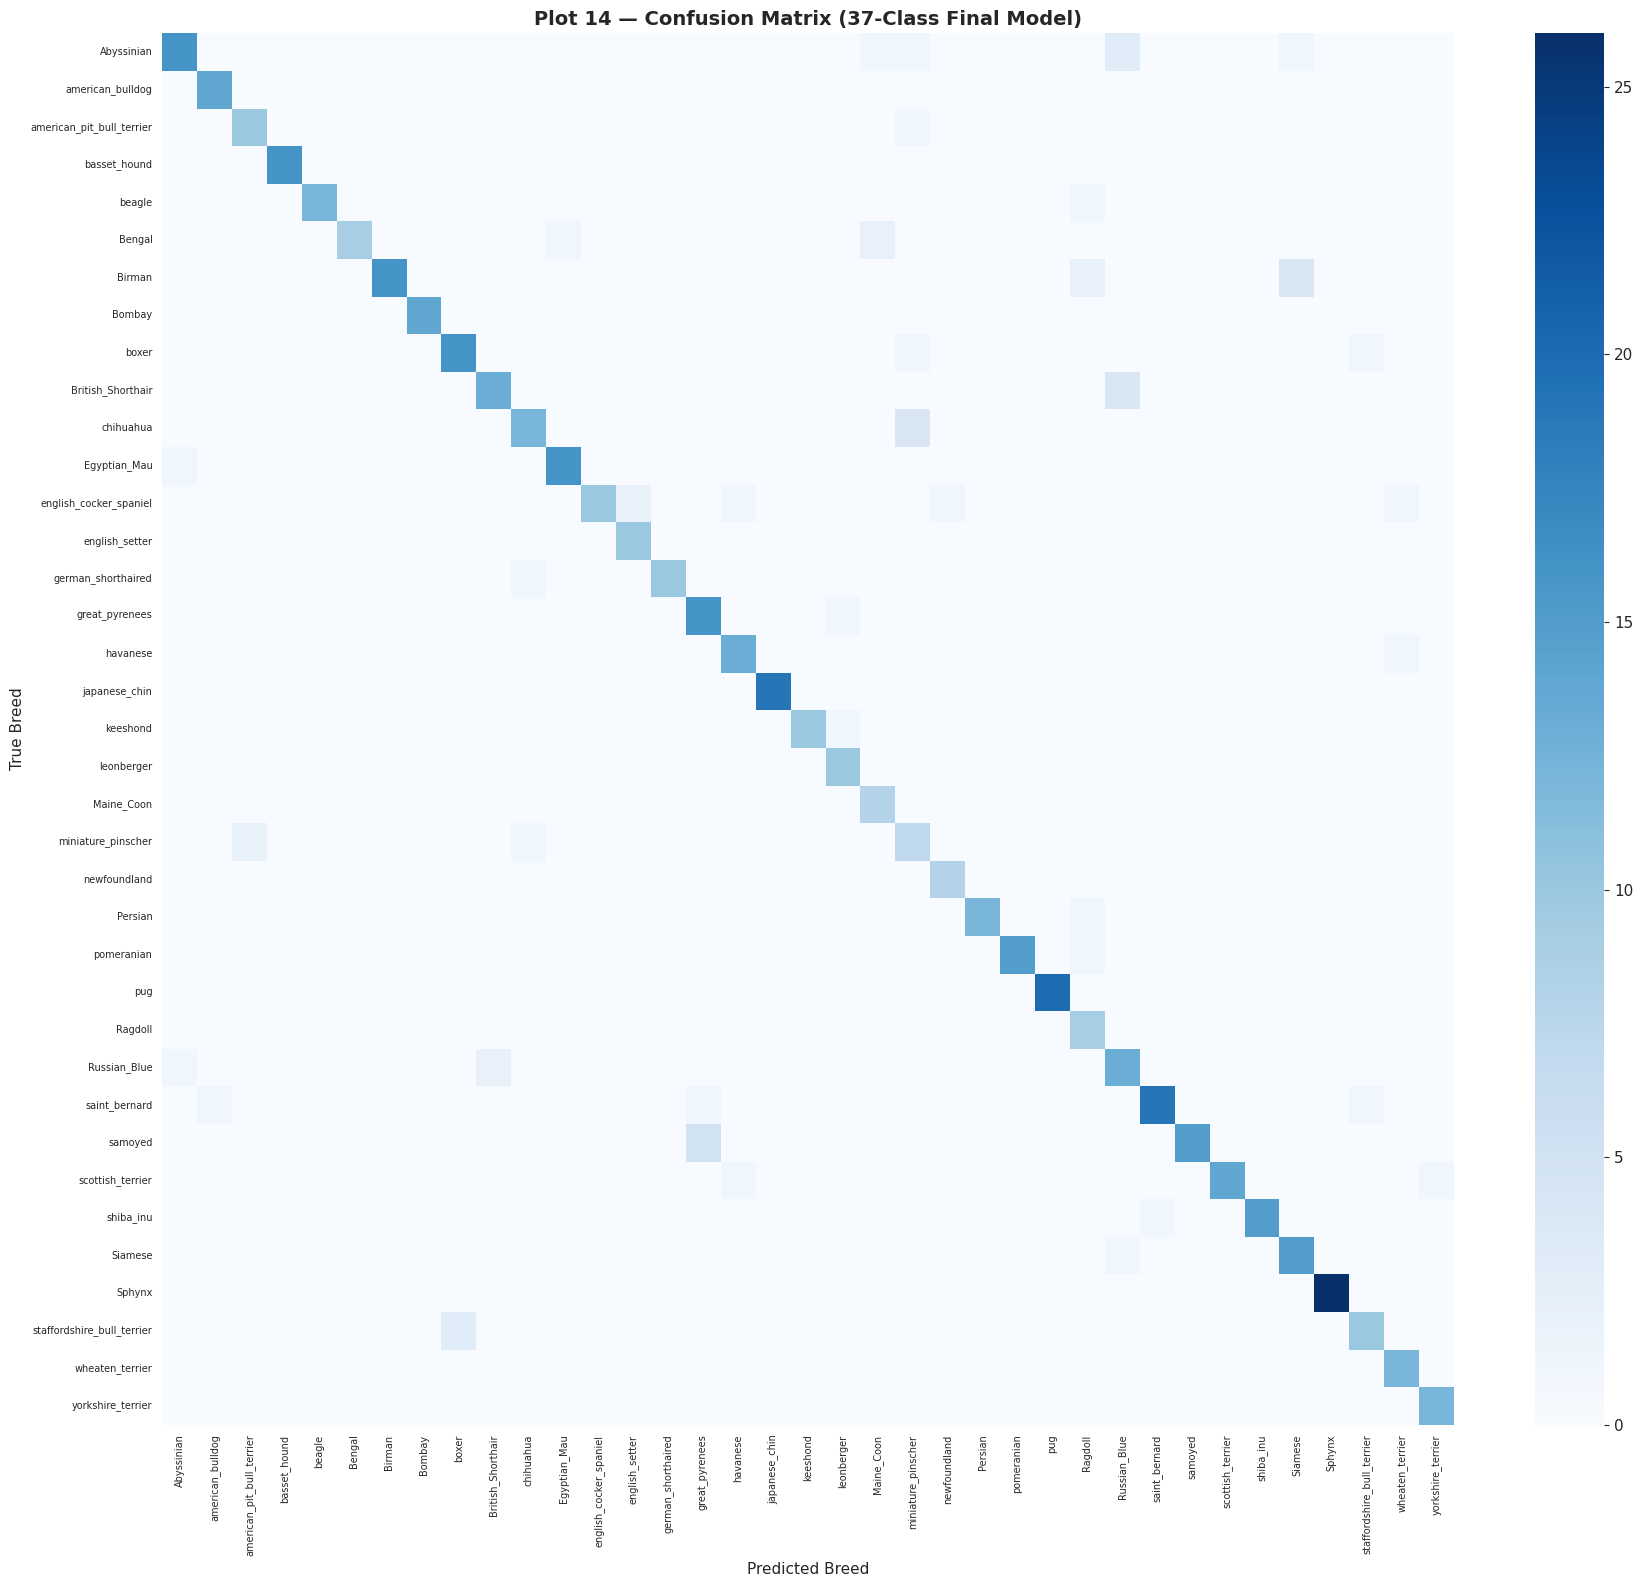


PER-CLASS ACCURACY
american_bulldog          100.00%
basset_hound              100.00%
Bombay                    100.00%
english_setter            100.00%
japanese_chin             100.00%
leonberger                100.00%
Maine_Coon                100.00%
newfoundland              100.00%
pug                       100.00%
Ragdoll                   100.00%
Sphynx                    100.00%
wheaten_terrier           100.00%
yorkshire_terrier         100.00%
Egyptian_Mau               94.12%
great_pyrenees             94.12%
pomeranian                 93.75%
shiba_inu                  93.75%
Siamese                    93.75%
havanese                   92.86%
beagle                     92.31%
Persian                    92.31%
american_pit_bull_terrier  90.91%
german_shorthaired         90.91%
keeshond                   90.91%
boxer                      88.89%
scottish_terrier           87.50%
saint_bernard              86.36%
Russian_Blue               81.25%
staffordshire_bull_terrier  

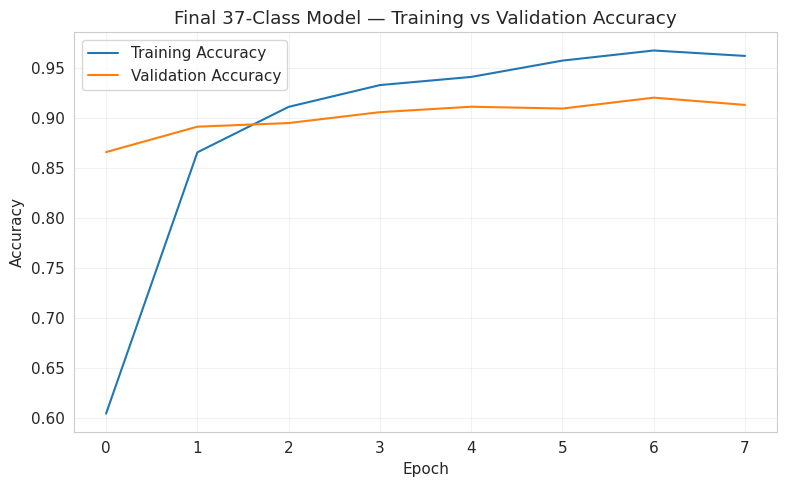

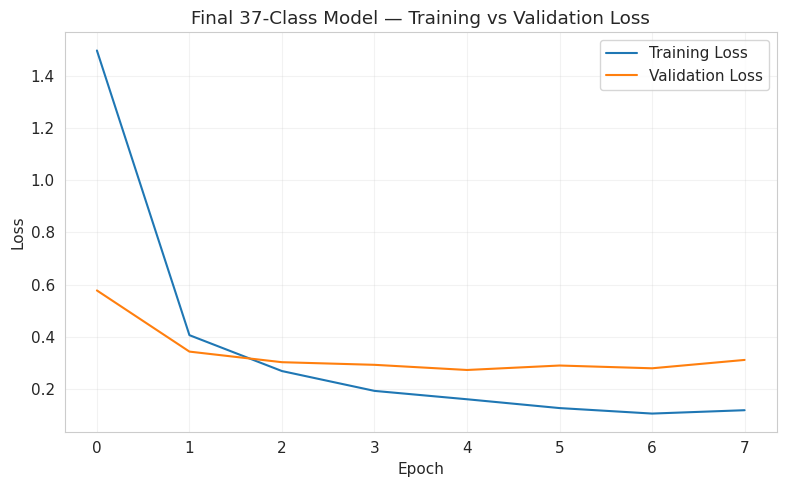


Number of misclassified images: 60


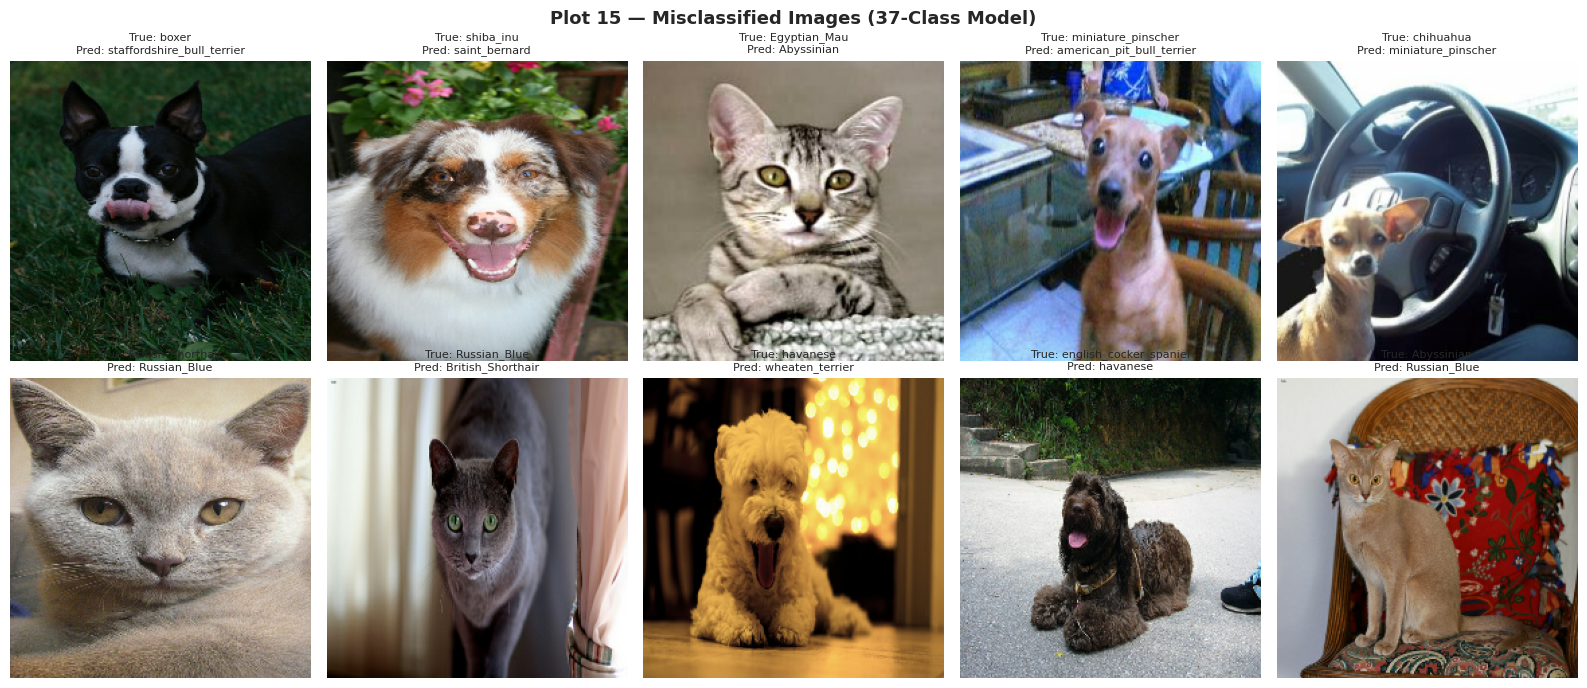


FINAL REPORT VALUES
Dataset             : Oxford-IIIT Pet
Number of classes   : 37
Image size          : 224x224x3
Model               : MobileNetV2 (ImageNet)
Dropout             : 0.5
Learning rate       : 0.001
Batch size          : 32
Epochs              : 8
Test accuracy       : 89.13%
Macro precision     : 89.50%
Macro recall        : 89.84%
Macro F1            : 88.95%
Training time       : 1153.95 sec
Total parameters    : 2,431,845
DONE


In [ ]:
# ============================================================
# FINAL FULL 37-CLASS EVALUATION
# Oxford-IIIT Pet | 37 Breeds | 224x224
# Selected configuration: LR=1e-3, Dropout=0.5
# ============================================================

import time
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

FINAL_IMG_SIZE = 224
FINAL_NUM_CLASSES = 37
FINAL_BATCH_SIZE = 32
FINAL_EPOCHS = 8
FINAL_LR = 1e-3
FINAL_DROPOUT = 0.5

print("=" * 60)
print("FINAL 37-CLASS EXPERIMENT")
print("=" * 60)


# ------------------------------------------------------------
# 2. LOAD FULL OXFORD-IIIT PET DATASET
#    No KEEP_BREEDS filtering
# ------------------------------------------------------------

(final_train, final_val, final_test), final_info = tfds.load(
    'oxford_iiit_pet',
    split=[
        'train[:70%]',
        'train[70%:85%]',
        'train[85%:]'
    ],
    with_info=True,
    as_supervised=True,
    shuffle_files=True
)

FINAL_BREEDS = final_info.features['label'].names

print("\nDataset:")
print("Number of breeds:", len(FINAL_BREEDS))
print("Breeds:", FINAL_BREEDS)


# ------------------------------------------------------------
# 3. PREPROCESSING
# ------------------------------------------------------------

def final_preprocess(img, lbl):
    img = tf.image.resize(
        img,
        [FINAL_IMG_SIZE, FINAL_IMG_SIZE]
    )
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, lbl


def final_augment(img, lbl):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, lbl


final_train_data = (
    final_train
    .map(final_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(final_augment, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(FINAL_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

final_val_data = (
    final_val
    .map(final_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(FINAL_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

final_test_data = (
    final_test
    .map(final_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(FINAL_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


# ------------------------------------------------------------
# 4. BUILD FINAL MODEL
#    MobileNetV2 + GAP + BN + Dropout(0.5) + Dense(128)
# ------------------------------------------------------------

tf.keras.backend.clear_session()
gc.collect()

final_base = MobileNetV2(
    input_shape=(FINAL_IMG_SIZE, FINAL_IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

final_base.trainable = False

x = final_base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(FINAL_DROPOUT)(x)
x = layers.Dense(128, activation='relu')(x)

final_output = layers.Dense(
    FINAL_NUM_CLASSES,
    activation='softmax'
)(x)

final_model = Model(
    inputs=final_base.input,
    outputs=final_output
)

final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINAL_LR
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel:")
print("Parameters:", f"{final_model.count_params():,}")
print("Image size:", f"{FINAL_IMG_SIZE}x{FINAL_IMG_SIZE}")
print("Classes:", FINAL_NUM_CLASSES)
print("Dropout:", FINAL_DROPOUT)
print("Learning rate:", FINAL_LR)


# ------------------------------------------------------------
# 5. TRAIN
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING")
print("=" * 60)

start_time = time.time()

final_history = final_model.fit(
    final_train_data,
    validation_data=final_val_data,
    epochs=FINAL_EPOCHS,
    verbose=1
)

final_training_time = time.time() - start_time

print(
    f"\nTraining time: {final_training_time:.2f} seconds"
)


# ------------------------------------------------------------
# 6. TEST EVALUATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)

test_loss, test_accuracy = final_model.evaluate(
    final_test_data,
    verbose=1
)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


# ------------------------------------------------------------
# 7. PREDICTIONS
# ------------------------------------------------------------

y_true = []
y_pred = []
test_images = []

for images, labels in final_test_data:

    predictions = final_model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

    test_images.extend(images.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
test_images = np.array(test_images)


# ------------------------------------------------------------
# 8. PRECISION / RECALL / F1
# ------------------------------------------------------------

precision = precision_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

print("\nFINAL METRICS")
print("-" * 40)
print(f"Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")
print(f"Time      : {final_training_time:.2f} sec")
print(f"Parameters: {final_model.count_params():,}")


# ------------------------------------------------------------
# 9. CONFUSION MATRIX — 37 x 37
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(FINAL_NUM_CLASSES)
)

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    cmap='Blues',
    annot=False,
    xticklabels=FINAL_BREEDS,
    yticklabels=FINAL_BREEDS
)

plt.title(
    'Plot 14 — Confusion Matrix (37-Class Final Model)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted Breed')
plt.ylabel('True Breed')

plt.xticks(
    rotation=90,
    fontsize=7
)

plt.yticks(
    rotation=0,
    fontsize=7
)

plt.tight_layout()

plt.savefig(
    './outputs/plot14_cm_37class.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ------------------------------------------------------------
# 10. PER-CLASS ACCURACY
# ------------------------------------------------------------

class_accuracy = np.divide(
    np.diag(cm),
    cm.sum(axis=1),
    out=np.zeros(FINAL_NUM_CLASSES),
    where=cm.sum(axis=1) != 0
)

class_results = sorted(
    zip(FINAL_BREEDS, class_accuracy),
    key=lambda x: x[1],
    reverse=True
)

print("\n" + "=" * 60)
print("PER-CLASS ACCURACY")
print("=" * 60)

for breed, acc in class_results:
    print(f"{breed:<25} {acc * 100:6.2f}%")

print(
    f"\nBest classified : "
    f"{class_results[0][0]} "
    f"({class_results[0][1] * 100:.2f}%)"
)

print(
    f"Worst classified: "
    f"{class_results[-1][0]} "
    f"({class_results[-1][1] * 100:.2f}%)"
)


# ------------------------------------------------------------
# 11. FINAL TRAINING / VALIDATION ACCURACY
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    final_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title(
    'Final 37-Class Model — Training vs Validation Accuracy'
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    './outputs/final_37class_accuracy.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ------------------------------------------------------------
# 12. FINAL TRAINING / VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    final_history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'Final 37-Class Model — Training vs Validation Loss'
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    './outputs/final_37class_loss.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ------------------------------------------------------------
# 13. MISCLASSIFIED IMAGES — PLOT 15
# ------------------------------------------------------------

wrong_indices = np.where(
    y_true != y_pred
)[0]

print("\nNumber of misclassified images:",
      len(wrong_indices))

n = min(10, len(wrong_indices))

fig, axes = plt.subplots(
    2,
    5,
    figsize=(16, 7)
)

fig.suptitle(
    'Plot 15 — Misclassified Images (37-Class Model)',
    fontsize=13,
    fontweight='bold'
)

for ax in axes.flat:
    ax.axis('off')

for i in range(n):

    idx = wrong_indices[i]

    # Undo MobileNetV2 [-1,1] preprocessing
    img = np.clip(
        (test_images[idx] + 1.0) / 2.0,
        0,
        1
    )

    axes.flat[i].imshow(img)

    axes.flat[i].set_title(
        f"True: {FINAL_BREEDS[y_true[idx]]}\n"
        f"Pred: {FINAL_BREEDS[y_pred[idx]]}",
        fontsize=8
    )

    axes.flat[i].axis('off')

plt.tight_layout()

plt.savefig(
    './outputs/plot15_wrong_37class.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ------------------------------------------------------------
# 14. FINAL SUMMARY — EASY TO COPY INTO REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL REPORT VALUES")
print("=" * 60)

print(f"Dataset             : Oxford-IIIT Pet")
print(f"Number of classes   : {FINAL_NUM_CLASSES}")
print(f"Image size          : {FINAL_IMG_SIZE}x{FINAL_IMG_SIZE}x3")
print(f"Model               : MobileNetV2 (ImageNet)")
print(f"Dropout             : {FINAL_DROPOUT}")
print(f"Learning rate       : {FINAL_LR}")
print(f"Batch size          : {FINAL_BATCH_SIZE}")
print(f"Epochs              : {FINAL_EPOCHS}")
print(f"Test accuracy       : {test_accuracy*100:.2f}%")
print(f"Macro precision     : {precision*100:.2f}%")
print(f"Macro recall        : {recall*100:.2f}%")
print(f"Macro F1            : {f1*100:.2f}%")
print(f"Training time       : {final_training_time:.2f} sec")
print(f"Total parameters    : {final_model.count_params():,}")

print("=" * 60)
print("DONE")
print("=" * 60)